# Task 2: Exploratory Data Analysis (EDA)

The purpose of this section is to explore the cleaned target dataset and understand price levels, distributions, trends, market differences, volatility, seasonality and relationships between variables.

The analysis focuses on Teff, Maize and Wheat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 General Dataset Overview

Before examining individual commodities and markets, we first review the main characteristics of the cleaned target dataset.

In [4]:
data_path = "../data/processed/ethiopian_food_prices_cleaned.csv"

target_df = pd.read_csv(data_path)

print("Cleaned dataset loaded successfully.")
print("Shape:", target_df.shape)

Cleaned dataset loaded successfully.
Shape: (19115, 17)


In [6]:
target_df["date"] = pd.to_datetime(target_df["date"])

print(target_df["date"].min())
print(target_df["date"].max())

2000-01-15 00:00:00
2026-07-15 00:00:00


In [8]:
target_df["commodity_group"].value_counts()

commodity_group
Maize    8704
Wheat    7132
Teff     3279
Name: count, dtype: int64

## 2.1 General

### 2.1.1 Descriptive Statistics

Descriptive statistics summarize the central tendency, spread, and range of food prices for each target commodity.

In [12]:
descriptive_stats = target_df.groupby("commodity_group")["price"].describe()

descriptive_stats.round(2)

,count,mean,std,min,25%,50%,75%,max
commodity_group,,,,,,,,
Maize,8704.0,1882.12,2028.65,29.60,445.0,776.0,3232.25,20000.0
Teff,3279.0,5487.25,3880.62,66.00,3343.5,4130.0,8052.50,18000.0
Wheat,7132.0,2760.43,3048.77,1.74,254.0,1600.0,4600.00,20000.0


In [11]:
# Compare mean and median prices

mean_median = target_df.groupby("commodity_group")["price"].agg(
    mean="mean",
    median="median"
)

mean_median.round(2)

,mean,median
commodity_group,,
Maize,1882.12,776.0
Teff,5487.25,4130.0
Wheat,2760.43,1600.0


### 2.1.2 Price Distributions

Price distributions are examined to understand the spread, skewness and presence of unusually high or low price observations for Teff, Maize and Wheat.

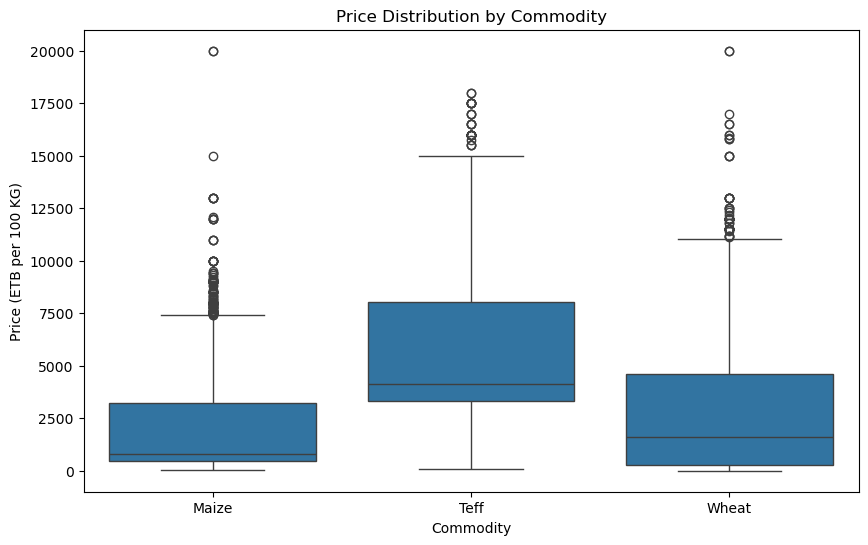

In [162]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=target_df,
    x="commodity_group",
    y="price"
)

plt.title("Price Distribution by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Price (ETB per 100 KG)")

plt.savefig(
    "../images/eda/Price Distribution by Commodity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price Distribution Histograms

Histograms are used to examine the shape and frequency of price observations for each commodity.

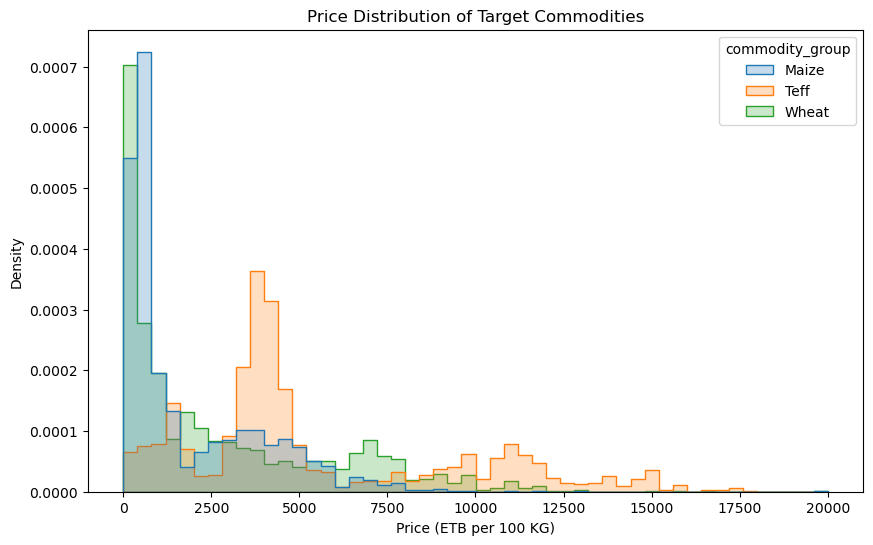

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=target_df,
    x="price",
    hue="commodity_group",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Price Distribution of Target Commodities")
plt.xlabel("Price (ETB per 100 KG)")
plt.ylabel("Density")

plt.savefig(
    "../images/eda/Price Distribution of Target Commodities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Individual distributions

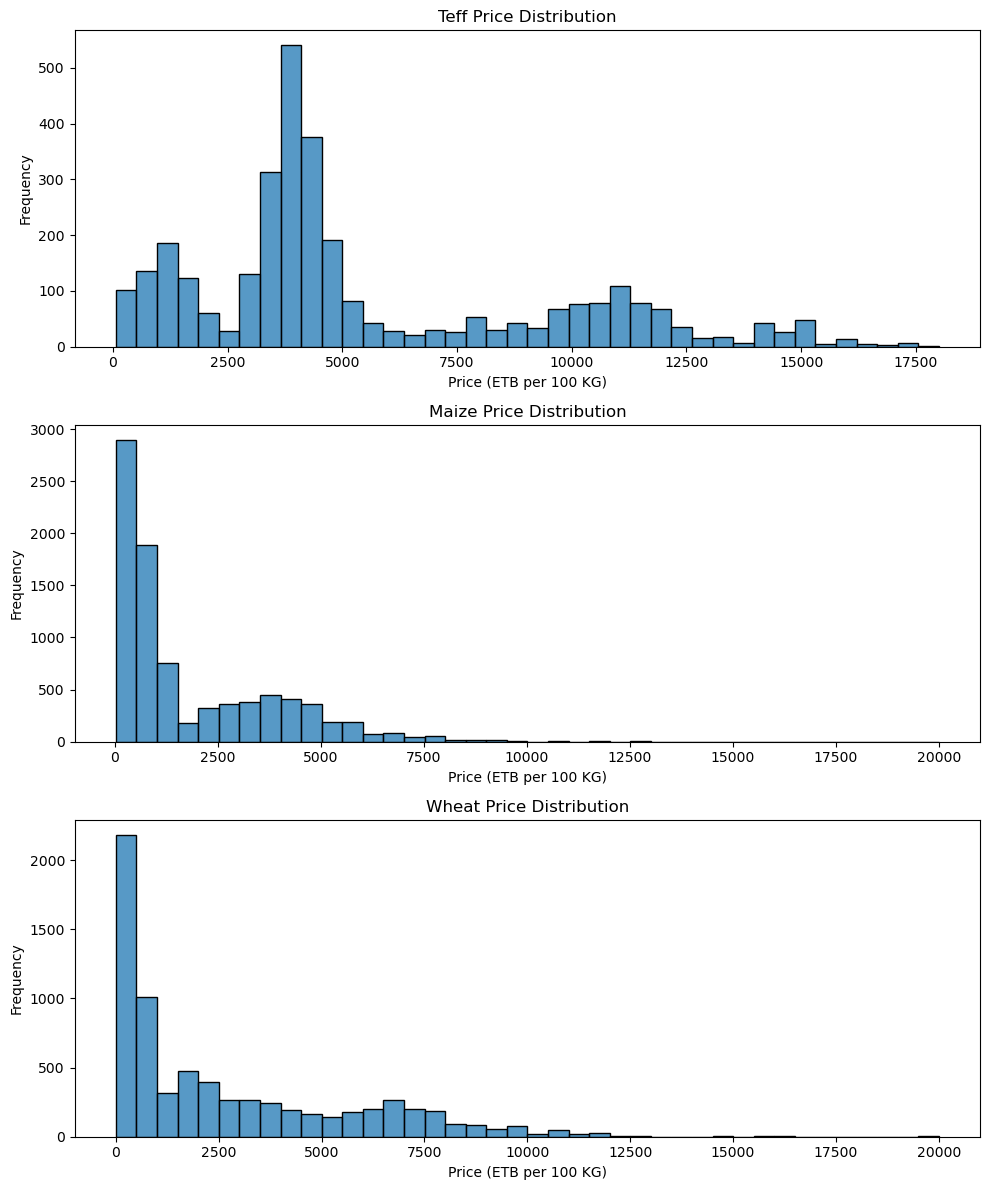

In [164]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

commodities = ["Teff", "Maize", "Wheat"]

for ax, commodity in zip(axes, commodities):
    sns.histplot(
        target_df[target_df["commodity_group"] == commodity]["price"],
        bins=40,
        ax=ax
    )
    
    ax.set_title(f"{commodity} Price Distribution")
    ax.set_xlabel("Price (ETB per 100 KG)")
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/eda/Commodity Price Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The price distributions show that Teff generally has a higher price level than Maize and Wheat. The distributions are right-skewed, with a concentration of observations at lower or moderate price levels and fewer observations at substantially higher prices.

The boxplots also show several high-price observations. These observations are not automatically treated as errors because genuine price spikes are relevant to the project's early-warning objective. Potential extreme observations will therefore be investigated rather than removed solely because of their magnitude.

### 2.1.3 Missingness Visualization

Missing values are visualized to understand which variables contain missing observations and whether missingness is concentrated in specific columns.

In [16]:
missing = target_df.isna().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

Columns with missing values:
admin1       5
admin2       5
latitude     5
longitude    5
dtype: int64


In [17]:
missing_percentage = (
    target_df.isna().mean() * 100
)

missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing percentage:")
print(missing_percentage.round(2))

Missing percentage:
admin1       0.03
admin2       0.03
latitude     0.03
longitude    0.03
dtype: float64


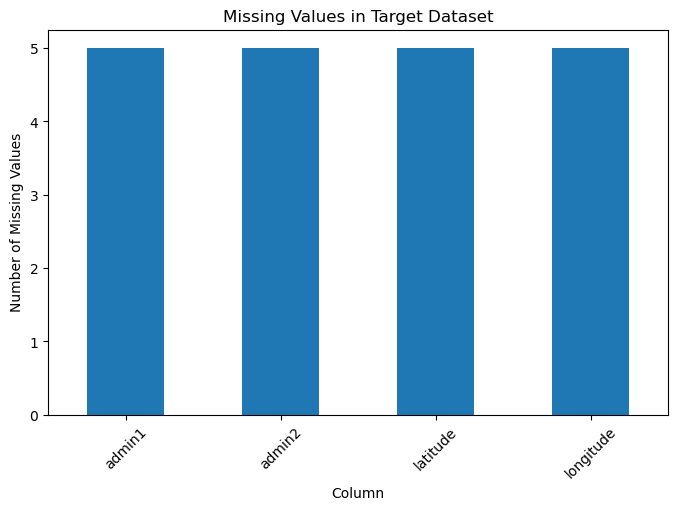

In [ ]:
plt.figure(figsize=(8, 5))

missing.plot(kind="bar")

plt.title("Missing Values in Target Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [19]:
missing_rows = target_df[target_df[[
    "admin1",
    "admin2",
    "latitude",
    "longitude"
]].isna().any(axis=1)]

missing_rows[
    [
        "date",
        "market",
        "commodity",
        "pricetype",
        "price",
        "admin1",
        "admin2",
        "latitude",
        "longitude"
    ]
]

,date,market,commodity,pricetype,price,admin1,admin2,latitude,longitude
9380,2020-04-15,Bichena,Teff (Sergegna),Wholesale,3250.0,NaN,NaN,NaN,NaN
9381,2020-04-15,Bichena,Teff (white),Wholesale,3550.0,NaN,NaN,NaN,NaN
10404,2020-10-15,Bichena,Maize (white),Wholesale,1290.0,NaN,NaN,NaN,NaN
10405,2020-10-15,Bichena,Teff (Sergegna),Wholesale,3665.0,NaN,NaN,NaN,NaN
10406,2020-10-15,Bichena,Teff (white),Wholesale,4035.0,NaN,NaN,NaN,NaN


## 2.2 Commodity Analysis

### 2.2.1 Teff Price Trends

The Teff price trend is examined over time to identify changes in price levels, long-term trends and periods of unusually high or low prices.

In [20]:
teff_df = target_df[
    target_df["commodity_group"] == "Teff"
].copy()

print("Teff observations:", len(teff_df))

Teff observations: 3279


In [24]:
teff_trend = (
    teff_df
    .groupby("date")["price"]
    .mean()
    .reset_index()
)

teff_trend.head(10)

,date,price
0,2000-01-15,222.00
1,2000-02-15,240.00
2,2000-03-15,244.00
3,2000-04-15,248.25
4,2000-05-15,248.50
5,2000-06-15,244.75
6,2000-07-15,251.75
7,2000-08-15,249.75
8,2000-09-15,247.25
9,2000-10-15,240.50


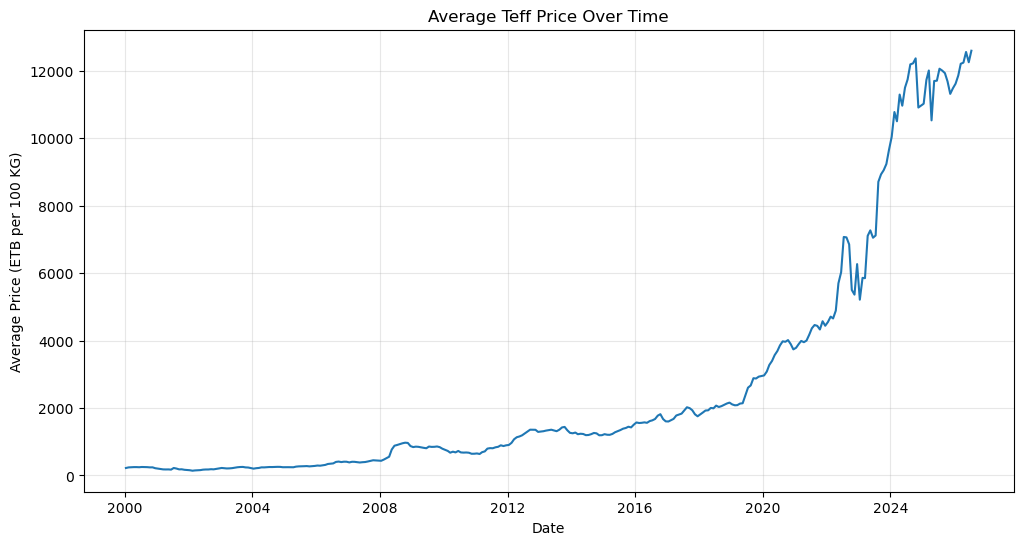

In [165]:
plt.figure(figsize=(12, 6))

plt.plot(
    teff_trend["date"],
    teff_trend["price"]
)

plt.title("Average Teff Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")

plt.grid(alpha=0.3)


plt.savefig(
    "../images/eda/Average Teff Price Over Time.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### rolling average

In [26]:
teff_trend["rolling_12m"] = (
    teff_trend["price"]
    .rolling(window=12)
    .mean()
)

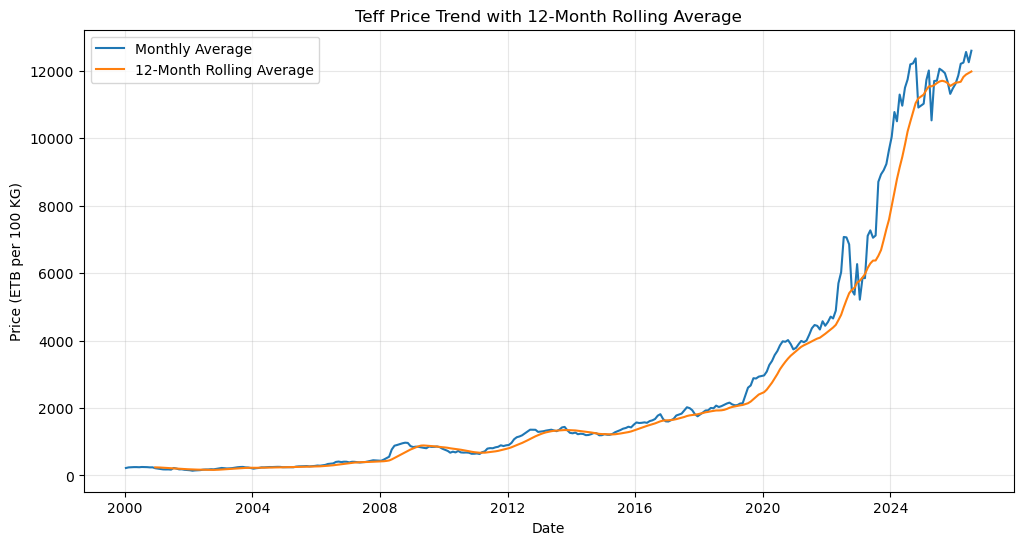

In [166]:
plt.figure(figsize=(12, 6))

plt.plot(
    teff_trend["date"],
    teff_trend["price"],
    label="Monthly Average"
)

plt.plot(
    teff_trend["date"],
    teff_trend["rolling_12m"],
    label="12-Month Rolling Average"
)

plt.title("Teff Price Trend with 12-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Price (ETB per 100 KG)")

plt.legend()
plt.grid(alpha=0.3)


plt.savefig(
    "../images/eda/Teff Price Trend with 12-Month Rolling Average.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### 2.2.2 Maize Price Trends

The Maize price trend is examined over time to identify long-term changes, short-term fluctuations and periods of unusually high or low prices.

In [28]:
maize_df = target_df[
    target_df["commodity_group"] == "Maize"
].copy()

print("Maize observations:", len(maize_df))

Maize observations: 8704


In [29]:
maize_trend = (
    maize_df
    .groupby("date")["price"]
    .mean()
    .reset_index()
)

maize_trend.head()

,date,price
0,2000-01-15,136.4375
1,2000-02-15,141.6250
2,2000-03-15,140.8750
3,2000-04-15,143.1250
4,2000-05-15,135.1250


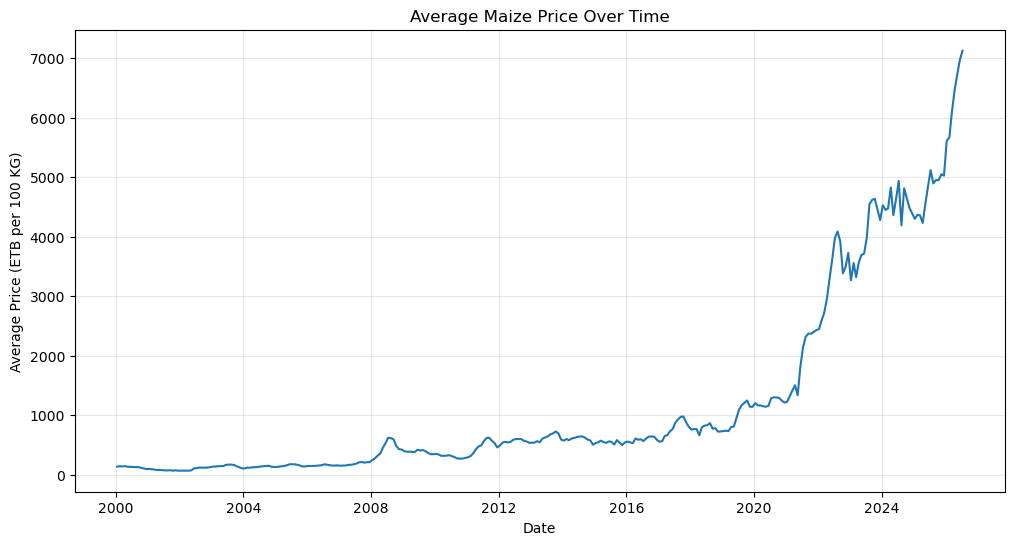

In [167]:
plt.figure(figsize=(12, 6))

plt.plot(
    maize_trend["date"],
    maize_trend["price"]
)

plt.title("Average Maize Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")

plt.grid(alpha=0.3)


plt.savefig(
    "../images/eda/Average Maize Price Over Time.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [31]:
maize_trend["rolling_12m"] = (
    maize_trend["price"]
    .rolling(window=12)
    .mean()
)

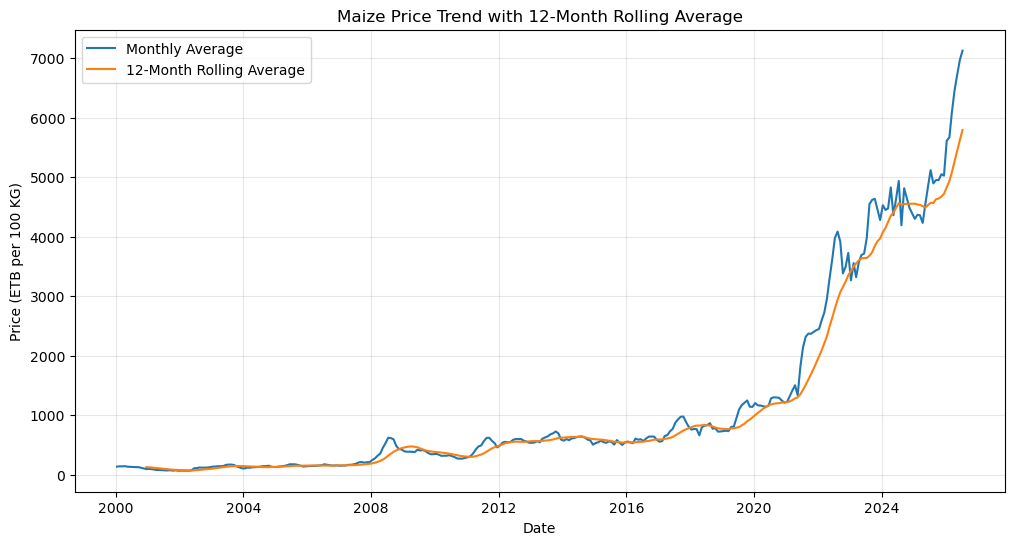

In [168]:
plt.figure(figsize=(12, 6))

plt.plot(
    maize_trend["date"],
    maize_trend["price"],
    label="Monthly Average"
)

plt.plot(
    maize_trend["date"],
    maize_trend["rolling_12m"],
    label="12-Month Rolling Average"
)

plt.title("Maize Price Trend with 12-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Price (ETB per 100 KG)")

plt.legend()
plt.grid(alpha=0.3)



plt.savefig(
    "../images/eda/Maize Price Trend with 12-Month Rolling Average.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### 2.2.3 Wheat Price Trends

The Wheat price trend is examined over time to identify long-term changes, short-term fluctuations and periods of unusually high or low prices.

In [33]:
wheat_df = target_df[
    target_df["commodity_group"] == "Wheat"
].copy()

print("Wheat observations:", len(wheat_df))

Wheat observations: 7132


In [34]:
wheat_trend = (
    wheat_df
    .groupby("date")["price"]
    .mean()
    .reset_index()
)

wheat_trend.head()

,date,price
0,2000-01-15,168.75
1,2000-02-15,173.50
2,2000-03-15,176.00
3,2000-04-15,203.25
4,2000-05-15,204.25


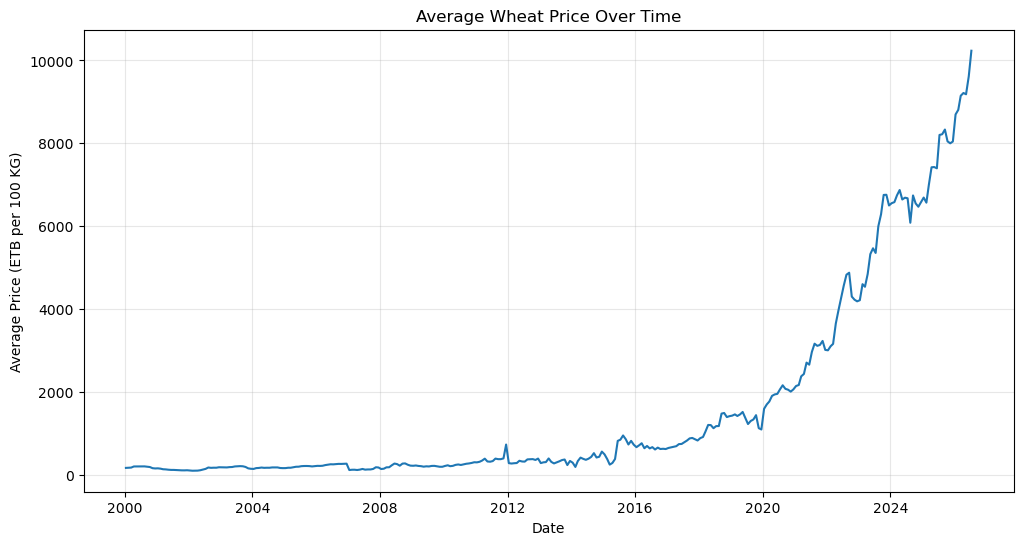

In [169]:
plt.figure(figsize=(12, 6))

plt.plot(
    wheat_trend["date"],
    wheat_trend["price"]
)

plt.title("Average Wheat Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")

plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Average Wheat Price Over Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
wheat_trend["rolling_12m"] = (
    wheat_trend["price"]
    .rolling(window=12)
    .mean()
)

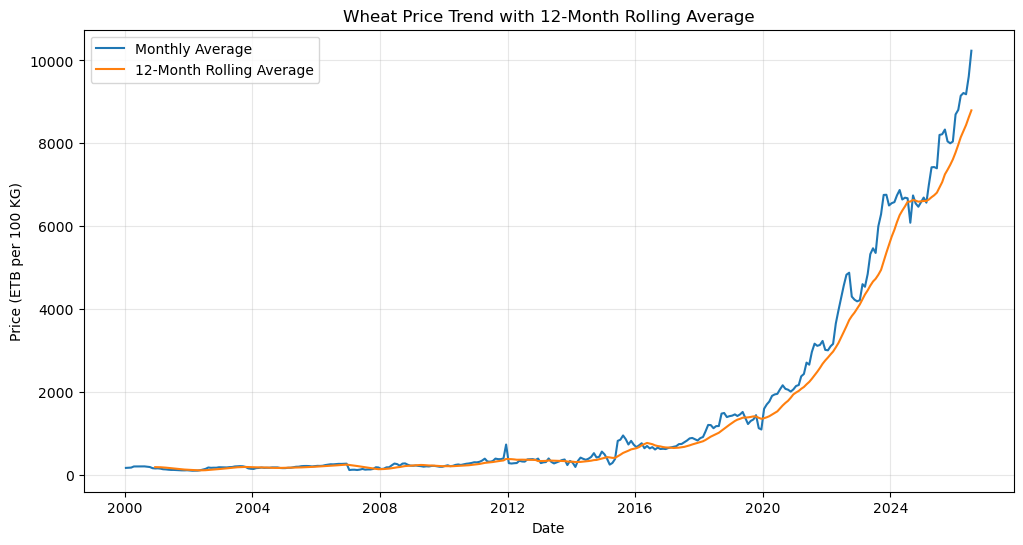

In [170]:
plt.figure(figsize=(12, 6))

plt.plot(
    wheat_trend["date"],
    wheat_trend["price"],
    label="Monthly Average"
)

plt.plot(
    wheat_trend["date"],
    wheat_trend["rolling_12m"],
    label="12-Month Rolling Average"
)

plt.title("Wheat Price Trend with 12-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Price (ETB per 100 KG)")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Wheat Price Trend with 12-Month Rolling Average.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 2.2.4 Commodity Comparison

The three target commodities are compared using their average prices over time to identify differences in overall price levels and common or different price movements.

In [40]:
commodity_trends = (
    target_df
    .groupby(["date", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

commodity_trends.head(9)

,date,commodity_group,price
0,2000-01-15,Maize,136.4375
1,2000-01-15,Teff,222.0000
2,2000-01-15,Wheat,168.7500
3,2000-02-15,Maize,141.6250
4,2000-02-15,Teff,240.0000
5,2000-02-15,Wheat,173.5000
6,2000-03-15,Maize,140.8750
7,2000-03-15,Teff,244.0000
8,2000-03-15,Wheat,176.0000


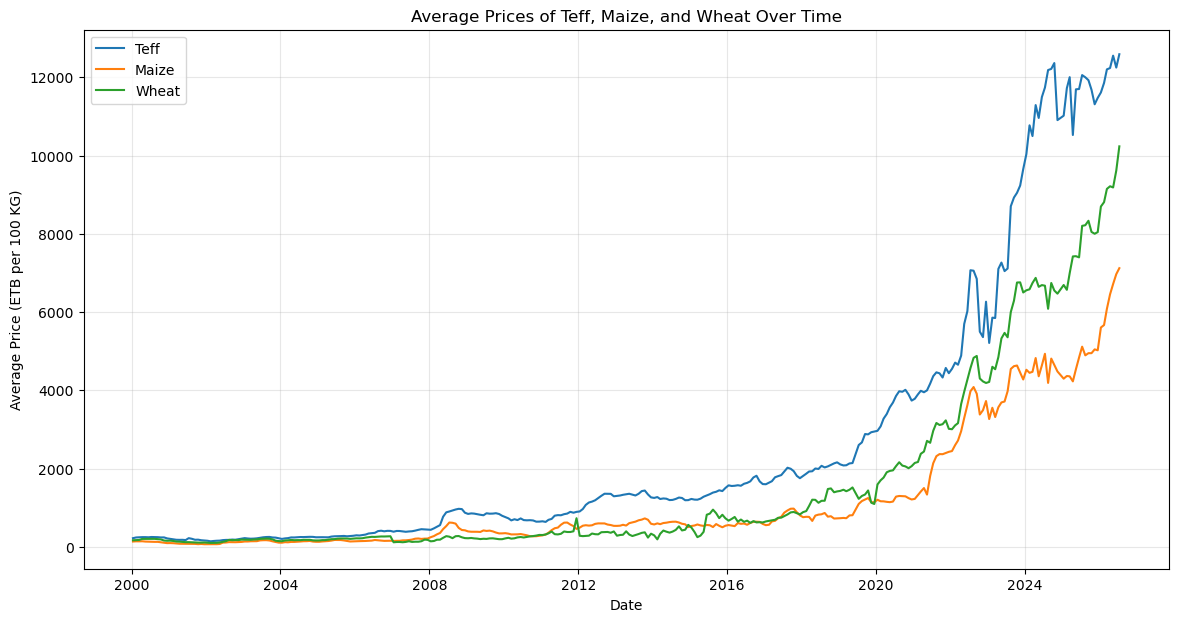

In [171]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = commodity_trends[
        commodity_trends["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["date"],
        data["price"],
        label=commodity
    )

plt.title("Average Prices of Teff, Maize, and Wheat Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig(
    "../images/eda/Average Prices of Teff, Maize, and Wheat Over Time.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# comparing avarage price

commodity_summary = (
    target_df
    .groupby("commodity_group")["price"]
    .agg(
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
)

commodity_summary.round(2)

,mean,median,minimum,maximum
commodity_group,,,,
Maize,1882.12,776.0,29.60,20000.0
Teff,5487.25,4130.0,66.00,18000.0
Wheat,2760.43,1600.0,1.74,20000.0


## Intrpretation

The commodity comparison shows that Teff consistently has the highest average price, followed by Wheat and Maize. All three commodities exhibit a long-term upward trend, but the increase becomes more pronounced after 2020. Teff shows the largest price levels and substantial fluctuations, while Maize remains comparatively lower. The commodities also show some similar movements over time, suggesting that they may be affected by common market conditions. These trends provide a basis for further analysis of volatility, seasonality, and potential price spikes.

## 2.3 Market Analysis

This section examines price differences across Ethiopian markets and regions.
### 2.3.1 Market Comparison

In [73]:
market_counts = target_df["market"].value_counts()

top_5_markets = market_counts.head(5).index

print("Selected markets:")
print(list(top_5_markets))

Selected markets:
['Diredawa', 'Addis Ababa', 'Shashemene', 'Mekele', 'Baher Dar']


In [ ]:
# Market × commodity average prices
market_commodity_prices = (
    target_df[
        target_df["market"].isin(top_5_markets)
    ]
    .groupby(["market", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

market_commodity_prices.round(2)

,market,commodity_group,price
0,Addis Ababa,Maize,454.31
1,Addis Ababa,Teff,1531.08
2,Addis Ababa,Wheat,760.20
3,Baher Dar,Maize,436.19
4,Baher Dar,Teff,2307.58
5,Baher Dar,Wheat,943.12
6,Diredawa,Maize,1068.49
7,Diredawa,Teff,4051.14
8,Diredawa,Wheat,1974.90
9,Mekele,Maize,1038.02


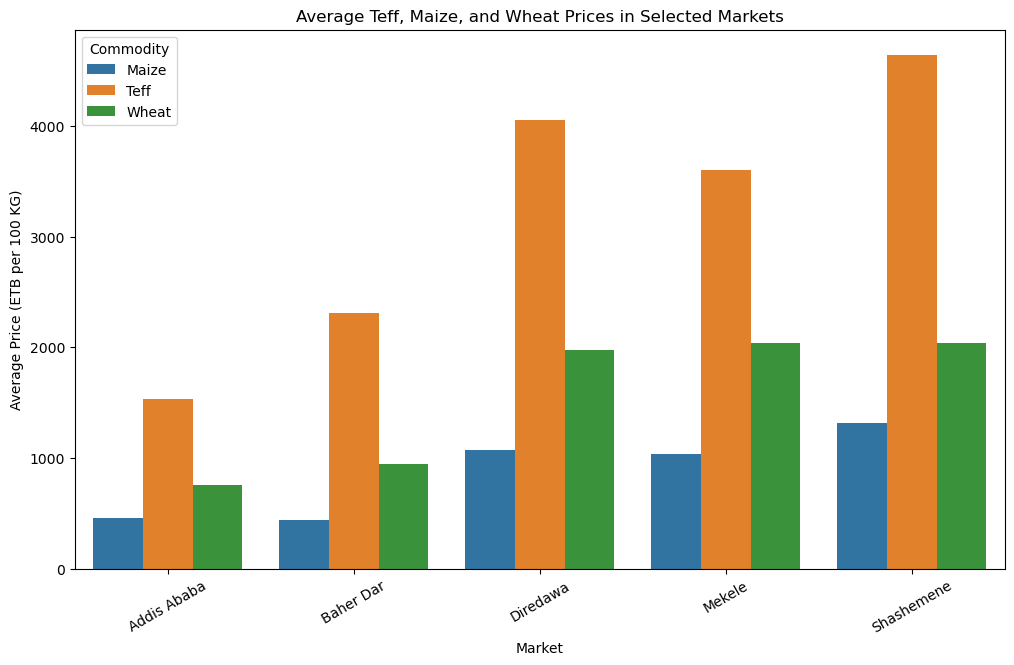

In [172]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=market_commodity_prices,
    x="market",
    y="price",
    hue="commodity_group"
)

plt.title("Average Teff, Maize, and Wheat Prices in Selected Markets")
plt.xlabel("Market")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.xticks(rotation=30)
plt.legend(title="Commodity")

plt.savefig(
    "../images/eda/Average Teff, Maize, and Wheat Prices in Selected Markets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Consistent Hierarchy: In every market, Teff is significantly the most expensive cereal, followed by Wheat, with Maize consistently being the cheapest.

Highest Price Points: Shashemene and Diredawa record the highest average prices for Teff, reaching above 4,500 ETB and 4,000 ETB per 100 KG, respectively

### 2.3.2 Regional Comparison

In [78]:
region_counts = target_df["admin1"].value_counts()

print("Number of regions:", target_df["admin1"].nunique())
region_counts

Number of regions: 11


admin1
Oromia         6491
Amhara         3622
Tigray         2399
SNNPR          2310
Somali         1286
Dire Dawa       832
Addis Ababa     826
Afar            699
Gambela         374
Harari          157
B. Gumuz        114
Name: count, dtype: int64

In [ ]:
# Regional price summary
region_prices = (
    target_df
    .groupby("admin1")["price"]
    .agg(
        mean="mean",
        median="median",
        observations="count"
    )
    .sort_values("mean", ascending=False)
)

region_prices.round(2)

,mean,median,observations
admin1,,,
Afar,7651.79,6200.00,699
Harari,4536.03,4000.00,157
B. Gumuz,4388.53,3900.00,114
Tigray,3041.01,800.00,2399
Somali,3035.69,2200.00,1286
Gambela,2957.73,2500.00,374
Oromia,2861.33,1836.00,6491
SNNPR,2753.37,2457.50,2310
Amhara,2237.47,1084.00,3622


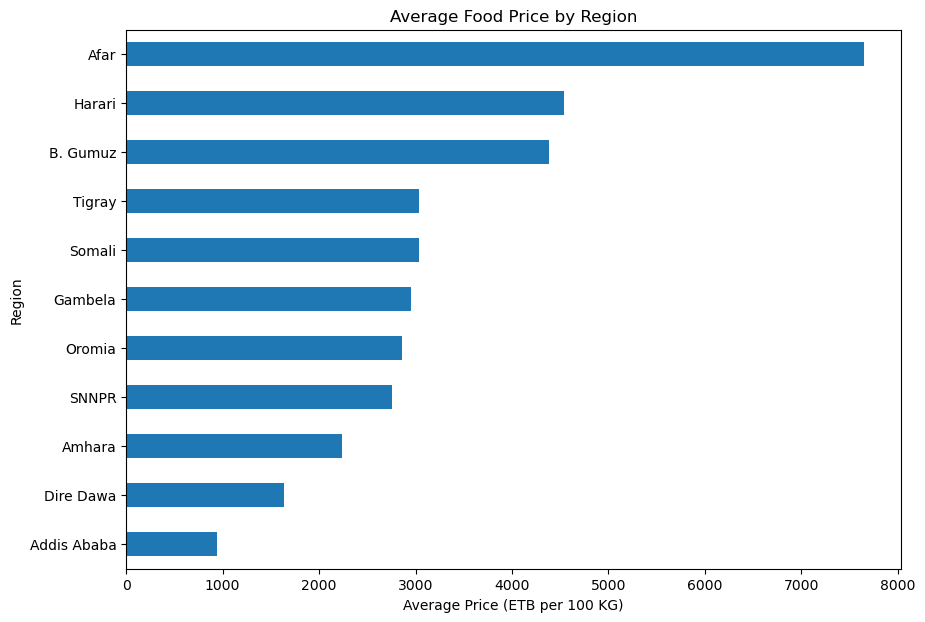

In [173]:
# Regional average price
plt.figure(figsize=(10, 7))

region_prices["mean"].sort_values().plot(kind="barh")

plt.title("Average Food Price by Region")
plt.xlabel("Average Price (ETB per 100 KG)")
plt.ylabel("Region")


plt.savefig(
    "../images/eda/Average Food Price by Region.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

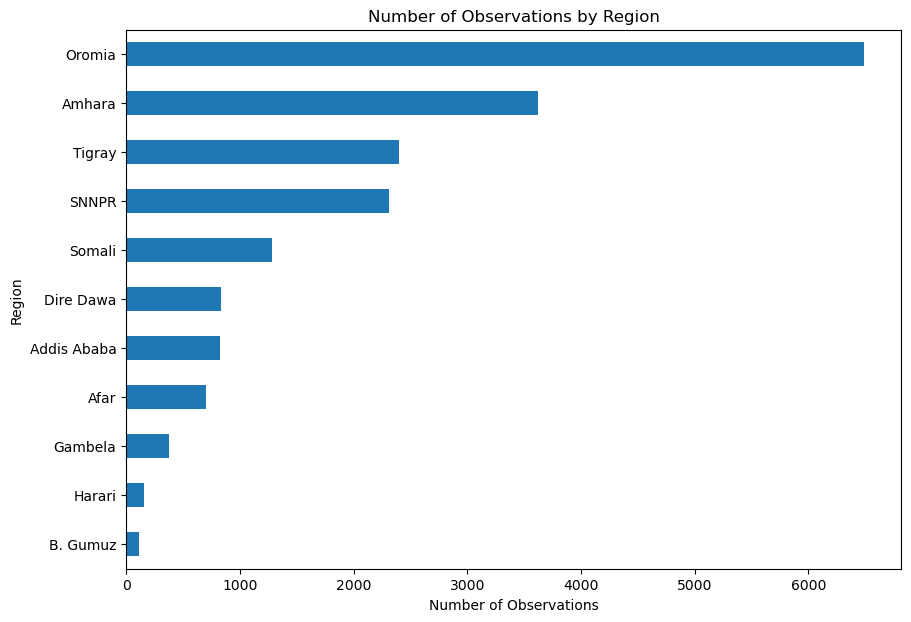

In [174]:
# Regional observation count
plt.figure(figsize=(10, 7))

region_counts.sort_values().plot(kind="barh")

plt.title("Number of Observations by Region")
plt.xlabel("Number of Observations")
plt.ylabel("Region")

plt.savefig(
    "../images/eda/Number of Observations by Region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# See when data collection started and ended for each region
target_df.groupby('admin1')['date'].agg(['min', 'max', 'count'])

,min,max,count
admin1,,,
Addis Ababa,2000-01-15,2021-10-15,826
Afar,2011-05-15,2026-07-15,699
Amhara,2000-01-15,2026-07-15,3622
B. Gumuz,2015-06-15,2026-07-15,114
Dire Dawa,2000-01-15,2026-07-15,832
Gambela,2011-05-15,2026-07-15,374
Harari,2020-01-15,2026-07-15,157
Oromia,2005-07-15,2026-07-15,6491
SNNPR,2005-07-15,2026-07-15,2310


### Interpretaion
Severe Price Disparity Across Regions: Afar records by far the highest average price (over 7,500 ETB per 100 KG), followed by Harari and Benishangul-Gumuz at around 4,500 ETB, while Addis Ababa reports the lowest average price at under 1,000 ETB.

Extreme Observation Imbalance: Oromia heavily dominates data coverage with roughly 6,500 observations, followed by Amhara (around 3,600), whereas Harari and Benishangul-Gumuz have negligible sample sizes of fewer than 200 records each.

Inverse Volume vs. Price Pattern: The regions with the highest reported price averages (Afar, Harari, and Benishangul-Gumuz) have some of the lowest observation counts, while major data-rich hubs like Addis Ababa show the lowest historical averages

### 2.3.3 Market-Level Trends

In [72]:
# Select top 5 markets
market_counts = target_df["market"].value_counts()
top_5_markets = market_counts.head(5).index

print("Selected markets:")
print(list(top_5_markets))

Selected markets:
['Diredawa', 'Addis Ababa', 'Shashemene', 'Mekele', 'Baher Dar']


In [82]:
# calculate market-level monthly prices
market_trends = (
    target_df[
        target_df["market"].isin(top_5_markets)
    ]
    .groupby(["date", "market", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

market_trends.head()

,date,market,commodity_group,price
0,2000-01-15,Addis Ababa,Maize,120.75
1,2000-01-15,Addis Ababa,Teff,222.00
2,2000-01-15,Addis Ababa,Wheat,168.75
3,2000-01-15,Baher Dar,Maize,115.50
4,2000-01-15,Diredawa,Maize,161.75


#### Teff Market-Level Trends

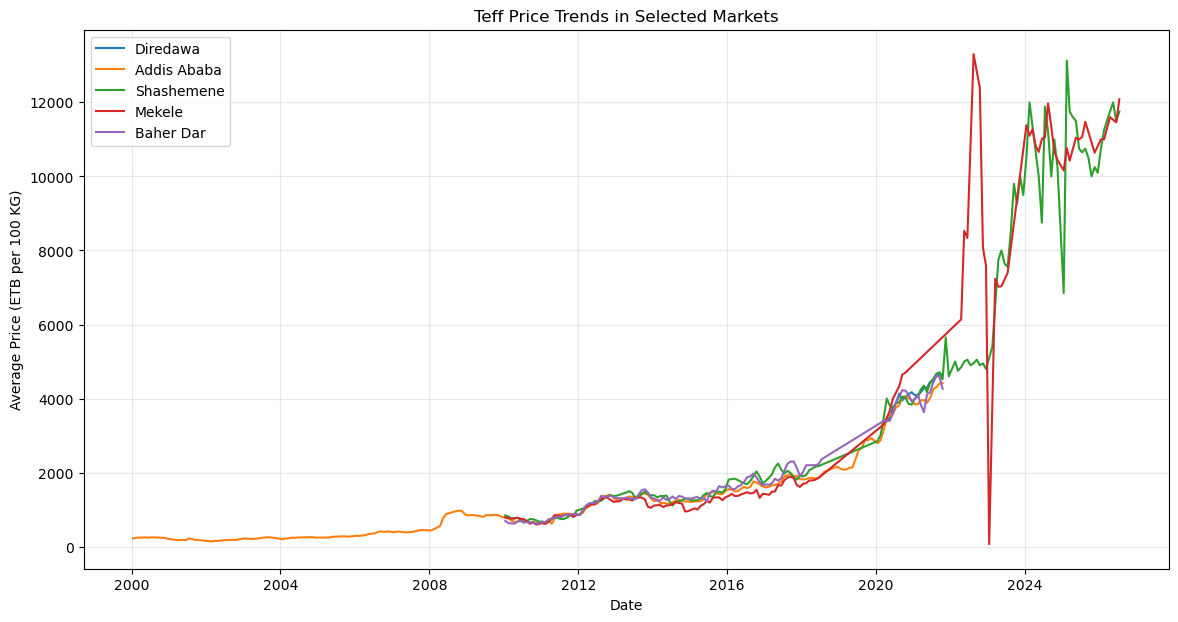

In [175]:
teff_market_trends = market_trends[
    market_trends["commodity_group"] == "Teff"
]

plt.figure(figsize=(14, 7))

for market in top_5_markets:
    
    data = teff_market_trends[
        teff_market_trends["market"] == market
    ]
    
    plt.plot(
        data["date"],
        data["price"],
        label=market
    )

plt.title("Teff Price Trends in Selected Markets")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Teff Price Trends in Selected Markets.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

#### Maize Market-Level Trends

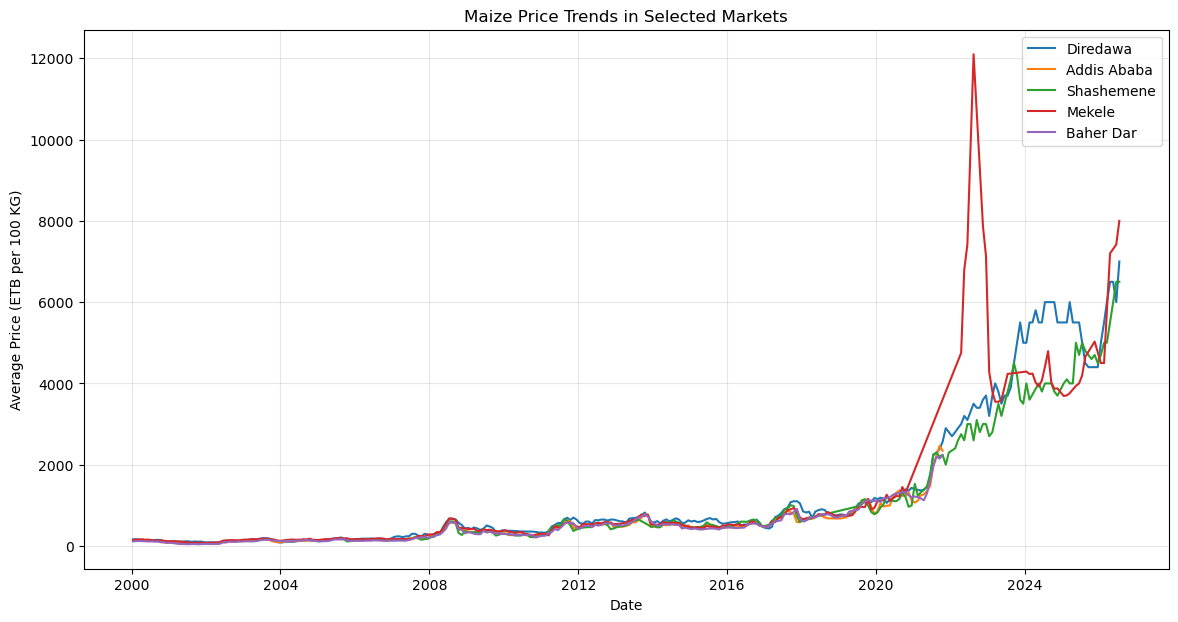

In [177]:
maize_market_trends = market_trends[
    market_trends["commodity_group"] == "Maize"
]

plt.figure(figsize=(14, 7))

for market in top_5_markets:
    
    data = maize_market_trends[
        maize_market_trends["market"] == market
    ]
    
    plt.plot(
        data["date"],
        data["price"],
        label=market
    )

plt.title("Maize Price Trends in Selected Markets")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Maize Price Trends in Selected Markets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Wheat Market-Level Trends

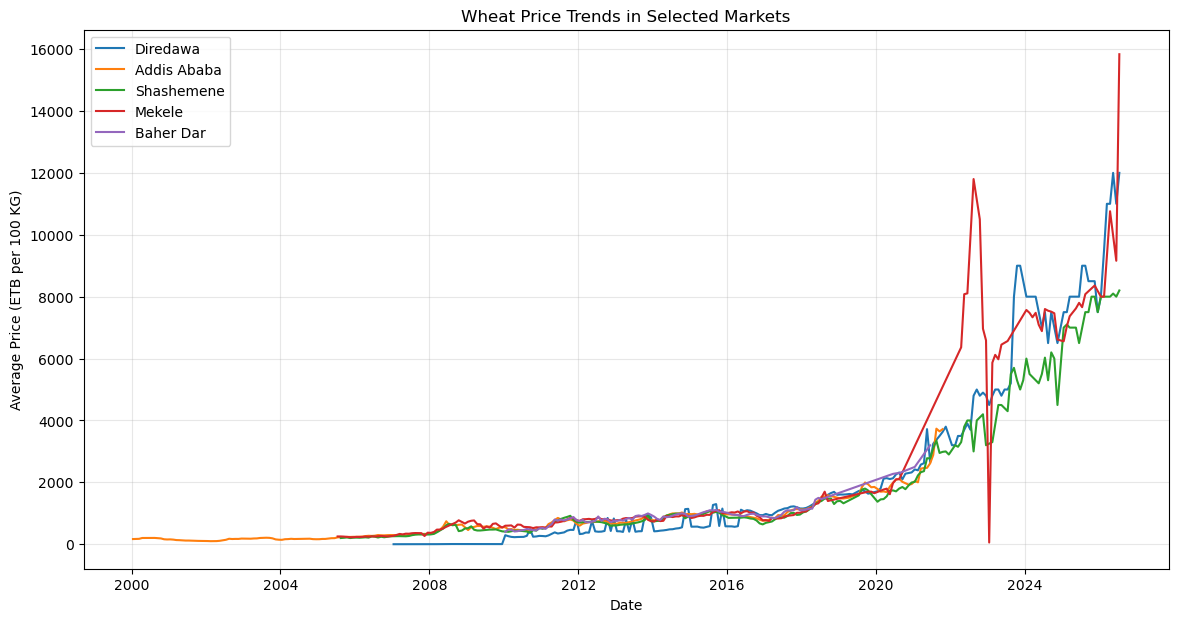

In [178]:
wheat_market_trends = market_trends[
    market_trends["commodity_group"] == "Wheat"
]

plt.figure(figsize=(14, 7))

for market in top_5_markets:
    
    data = wheat_market_trends[
        wheat_market_trends["market"] == market
    ]
    
    plt.plot(
        data["date"],
        data["price"],
        label=market
    )

plt.title("Wheat Price Trends in Selected Markets")
plt.xlabel("Date")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Wheat Price Trends in Selected Markets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation
Pre-2020 Stability: From 2000 to 2020, prices were remarkably stable and low, remaining almost entirely under 2,000 ETB

Post-2020 Inflation: A massive structural shift caused prices to skyrocket across all markets, pushing them into the 6,000 to 12,000 ETB range

Extreme Volatility: Mekele suffered an isolated, dramatic price spike well above 12,000 ETB around 2022–2023

The Average Price Trap: This timeline explains why older markets like Addis Ababa have low all-time averages; two decades of cheap historical data drag down their overall mathematical mean

## 2.4 Volatility Analysis

This section examines the variability and instability of food prices over time.

2.4.1 Percentage Changes



In [86]:
commodity_monthly = (
    target_df
    .groupby(["date", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

commodity_monthly.head()

,date,commodity_group,price
0,2000-01-15,Maize,136.4375
1,2000-01-15,Teff,222.0000
2,2000-01-15,Wheat,168.7500
3,2000-02-15,Maize,141.6250
4,2000-02-15,Teff,240.0000


In [ ]:
# Calculate percentage change
commodity_monthly["price_change_pct"] = (
    commodity_monthly
    .groupby("commodity_group")["price"]
    .pct_change() * 100
)

commodity_monthly.head(10)

,date,commodity_group,price,price_change_pct
0,2000-01-15,Maize,136.4375,NaN
1,2000-01-15,Teff,222.0000,NaN
2,2000-01-15,Wheat,168.7500,NaN
3,2000-02-15,Maize,141.6250,3.802107
4,2000-02-15,Teff,240.0000,8.108108
5,2000-02-15,Wheat,173.5000,2.814815
6,2000-03-15,Maize,140.8750,-0.529568
7,2000-03-15,Teff,244.0000,1.666667
8,2000-03-15,Wheat,176.0000,1.440922
9,2000-04-15,Maize,143.1250,1.597161


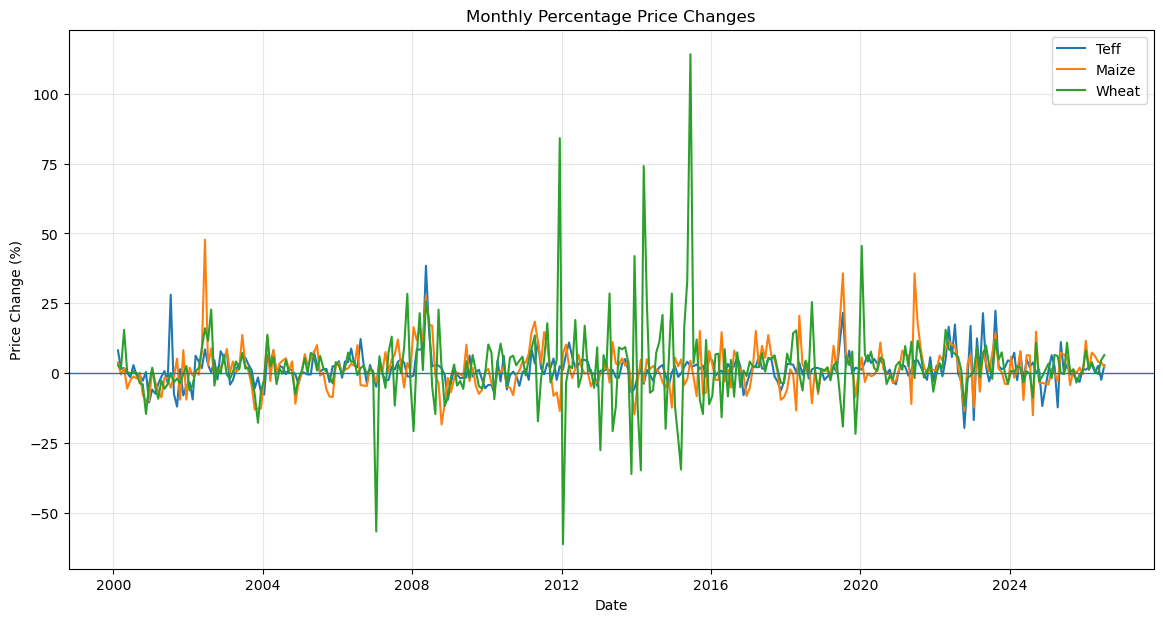

In [179]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = commodity_monthly[
        commodity_monthly["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["date"],
        data["price_change_pct"],
        label=commodity
    )

plt.axhline(0, linewidth=1)

plt.title("Monthly Percentage Price Changes")
plt.xlabel("Date")
plt.ylabel("Price Change (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/Monthly Percentage Price Changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Wheat is Highly Volatile: The percentage changes for wheat are extremely erratic. Around 2015–2016, it saw a massive spike of over 110% in a single month, and it also recorded huge drops (greater than -50%) in 2007 and 2012.

Maize Price Shocks: Maize experienced notable surges, such as a nearly 50% jump in the 2002–2003 period, along with large monthly swings in 2008, 2019, and 2021.

Teff is Relatively Stable: Compared to wheat, the monthly percentage changes for Teff are much flatter and less volatile, though there are still distinct spikes around 2008 and 2023.

### 2.4.2 Rolling Mean

In [91]:
commodity_monthly["rolling_mean_12m"] = (
    commodity_monthly
    .groupby("commodity_group")["price"]
    .transform(
        lambda x: x.rolling(window=12).mean()
    )
)

commodity_monthly.head(1500)

,date,commodity_group,price,price_change_pct,rolling_mean_12m
0,2000-01-15,Maize,136.437500,NaN,NaN
1,2000-01-15,Teff,222.000000,NaN,NaN
2,2000-01-15,Wheat,168.750000,NaN,NaN
3,2000-02-15,Maize,141.625000,3.802107,NaN
4,2000-02-15,Teff,240.000000,8.108108,NaN
...,...,...,...,...,...
945,2026-06-15,Teff,12248.882353,-2.426387,11930.265241
946,2026-06-15,Wheat,9617.222222,4.704042,8627.172525
947,2026-07-15,Maize,7122.253521,2.187243,5790.567021
948,2026-07-15,Teff,12590.406250,2.788205,11974.722707


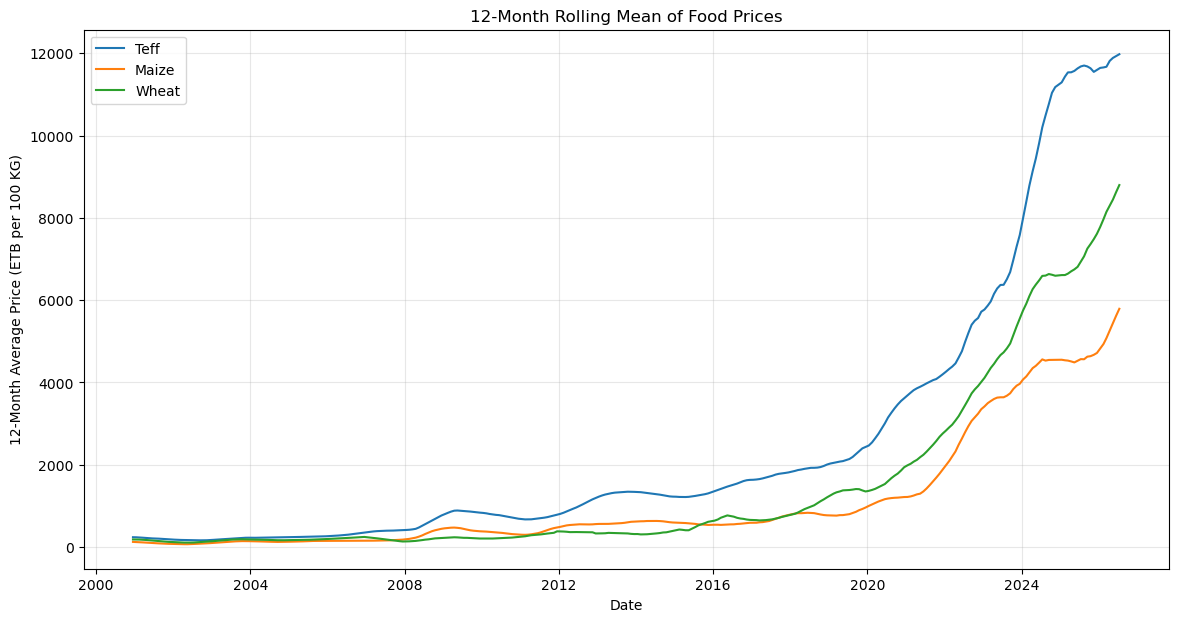

In [180]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = commodity_monthly[
        commodity_monthly["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["date"],
        data["rolling_mean_12m"],
        label=commodity
    )

plt.title("12-Month Rolling Mean of Food Prices")
plt.xlabel("Date")
plt.ylabel("12-Month Average Price (ETB per 100 KG)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/eda/12-Month Average Price (ETB per 100 KG).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pre-2020 Stability: From the year 2000 through 2019, the 12-month rolling average for all three commodities was incredibly stable and remained well below 2,000 ETB.

Post-2020 Inflation Surge: Following 2020, a massive structural shift occurred. The rolling averages for all three crops climbed exponentially, indicating severe, sustained inflation rather than just short-term shocks.

Price Hierarchy: Teff remains the most expensive by a wide margin (peaking near 12,000 ETB), followed by Wheat (approaching 9,000 ETB), and Maize (approaching 6,000 ETB).

### 2.4.3 Rolling Standard Deviation

In [95]:
commodity_monthly["rolling_std_12m"] = (
    commodity_monthly
    .groupby("commodity_group")["price_change_pct"]
    .transform(
        lambda x: x.rolling(window=12).std()
    )
)

commodity_monthly[
    ["date", "commodity_group", "price_change_pct", "rolling_std_12m"]
].head(150)

,date,commodity_group,price_change_pct,rolling_std_12m
0,2000-01-15,Maize,NaN,NaN
1,2000-01-15,Teff,NaN,NaN
2,2000-01-15,Wheat,NaN,NaN
3,2000-02-15,Maize,3.802107,NaN
4,2000-02-15,Teff,8.108108,NaN
...,...,...,...,...
145,2004-01-15,Teff,-7.727273,4.731962
146,2004-01-15,Wheat,-2.372881,6.534813
147,2004-02-15,Maize,13.260972,9.061299
148,2004-02-15,Teff,6.527094,5.014943


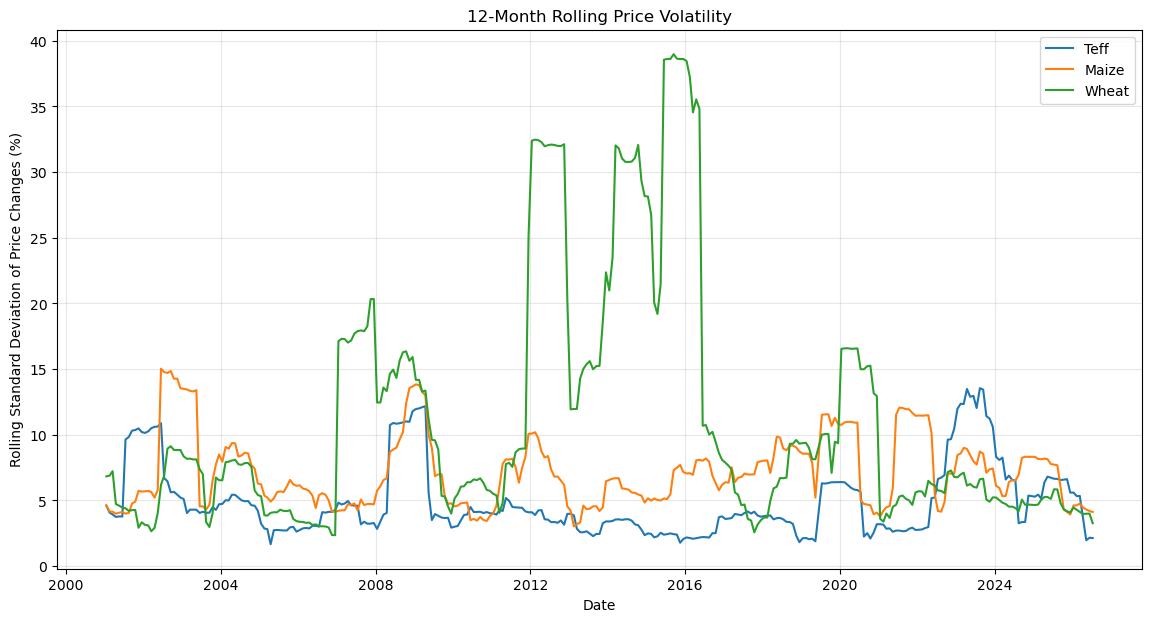

In [181]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = commodity_monthly[
        commodity_monthly["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["date"],
        data["rolling_std_12m"],
        label=commodity
    )

plt.title("12-Month Rolling Price Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation of Price Changes (%)")
plt.legend()
plt.grid(alpha=0.3)


plt.savefig(
    "../images/eda/12-Month Rolling Price Volatility.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Wheat is the Most Volatile: Wheat suffered extreme volatility episodes, with rolling standard deviations repeatedly surging past 30% and peaking near 39% between 2012 and 2016.

Maize Has Periodic Shocks: Maize displays consistent cyclical swings, with volatility regularly spiking into the 10%–15% range during drought and harvest seasons.

Teff Shifted Late: Teff maintained the lowest long-term volatility (consistently below 5%) before experiencing an unprecedented spike to ~14% in 2023–2024.

### 2.4.4 Volatility Comparison


In [97]:
volatility_summary = (
    commodity_monthly
    .groupby("commodity_group")["price_change_pct"]
    .agg(
        mean_change="mean",
        volatility="std",
        minimum_change="min",
        maximum_change="max"
    )
)

volatility_summary.round(2)

,mean_change,volatility,minimum_change,maximum_change
commodity_group,,,,
Maize,1.54,7.76,-18.41,47.75
Teff,1.44,5.64,-19.69,38.43
Wheat,2.22,14.00,-61.30,114.17


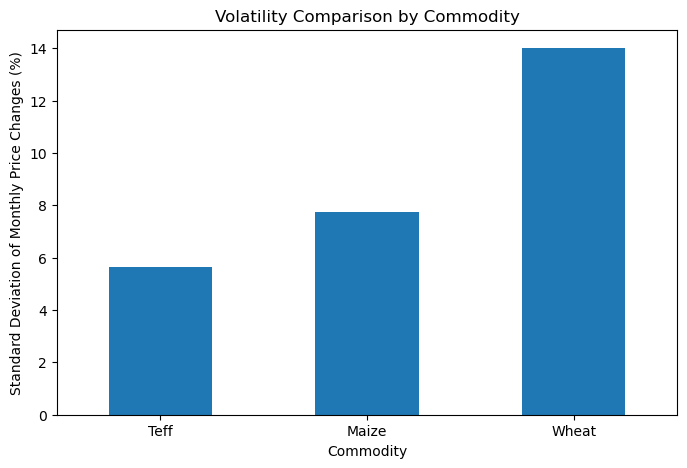

In [182]:
plt.figure(figsize=(8, 5))

volatility_summary["volatility"].sort_values().plot(
    kind="bar"
)

plt.title("Volatility Comparison by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Standard Deviation of Monthly Price Changes (%)")
plt.xticks(rotation=0)

plt.savefig(
    "../images/eda/Volatility Comparison by Commodity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

For volatility,we calculated monthly percentage price changes and then compared their standard deviations. Wheat had the highest volatility at 14%, followed by Maize at 7.76% and Teff at 5.64%. Wheat also had the largest individual monthly movements, ranging from a 61.3% decrease to a 114.17% increase. 

This suggests that Wheat prices experienced greater month-to-month instability in our dataset. 

## 2.5 Seasonality Analysis

This section examines whether food prices follow recurring patterns over time.

### 2.5.1 Monthly Patterns

In [99]:
target_df["month"] = target_df["date"].dt.month
target_df["month_name"] = target_df["date"].dt.month_name()

target_df[["date", "month", "month_name"]].head()

,date,month,month_name
0,2000-01-15,1,January
1,2000-01-15,1,January
2,2000-01-15,1,January
3,2000-01-15,1,January
4,2000-01-15,1,January


In [101]:
# Avarage price by month
monthly_pattern = (
    target_df
    .groupby(["month", "month_name", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

monthly_pattern.head(10)

,month,month_name,commodity_group,price
0,1,January,Maize,1761.611928
1,1,January,Teff,5135.925840
2,1,January,Wheat,2485.300870
3,2,February,Maize,1757.813373
4,2,February,Teff,5347.969886
5,2,February,Wheat,2585.330080
6,3,March,Maize,1864.680559
7,3,March,Teff,4886.562759
8,3,March,Wheat,2696.047224
9,4,April,Maize,1879.301573


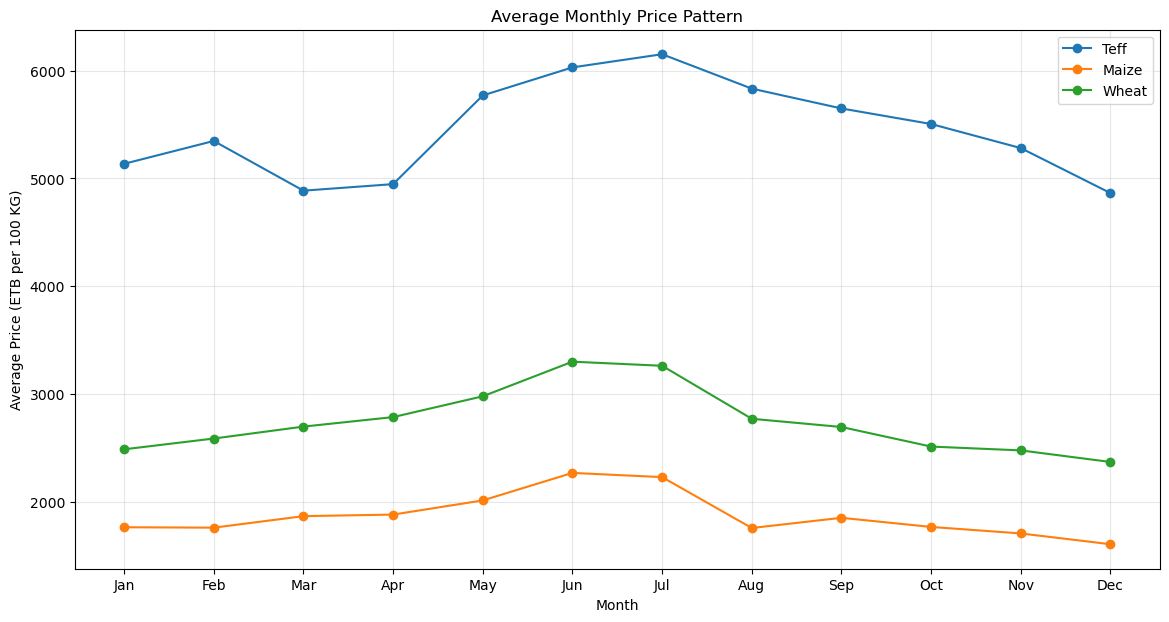

In [183]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    data = monthly_pattern[
        monthly_pattern["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["month"],
        data["price"],
        marker="o",
        label=commodity
    )

plt.title("Average Monthly Price Pattern")
plt.xlabel("Month")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../images/seasonal/Average Monthly Price Pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The seasonal analysis shows a clear common pattern across the three commodities. Prices generally peak around June and July and then decline from August toward November and December. This pattern is consistent with the timing of the pre-harvest lean period and the arrival of harvest supplies. Teff remains more expensive than Wheat and Maize throughout the year

### 2.5.2 Seasonal Patterns

In [109]:

target_df = target_df.sort_values("date").copy()

# Extract month information
target_df["month"] = target_df["date"].dt.month
target_df["month_name"] = target_df["date"].dt.month_name()

target_df[["date", "commodity_group", "price", "month", "month_name"]].head()

,date,commodity_group,price,month,month_name
0,2000-01-15,Maize,120.75,1,January
1,2000-01-15,Teff,222.00,1,January
2,2000-01-15,Wheat,168.75,1,January
3,2000-01-15,Maize,115.50,1,January
4,2000-01-15,Maize,161.75,1,January


In [107]:
# Monthly average prices
seasonal_avg = (
    target_df
    .groupby(["month", "month_name", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

seasonal_avg.head(10)

,month,month_name,commodity_group,price
0,1,January,Maize,1761.611928
1,1,January,Teff,5135.925840
2,1,January,Wheat,2485.300870
3,2,February,Maize,1757.813373
4,2,February,Teff,5347.969886
5,2,February,Wheat,2585.330080
6,3,March,Maize,1864.680559
7,3,March,Teff,4886.562759
8,3,March,Wheat,2696.047224
9,4,April,Maize,1879.301573


In [108]:
# Calander order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

seasonal_avg["month_name"] = pd.Categorical(
    seasonal_avg["month_name"],
    categories=month_order,
    ordered=True
)

seasonal_avg = seasonal_avg.sort_values(
    ["commodity_group", "month"]
)

seasonal_avg

,month,month_name,commodity_group,price
0,1,January,Maize,1761.611928
3,2,February,Maize,1757.813373
6,3,March,Maize,1864.680559
9,4,April,Maize,1879.301573
12,5,May,Maize,2010.733974
15,6,June,Maize,2266.188780
18,7,July,Maize,2227.087936
21,8,August,Maize,1754.597708
24,9,September,Maize,1849.383061
27,10,October,Maize,1764.510910


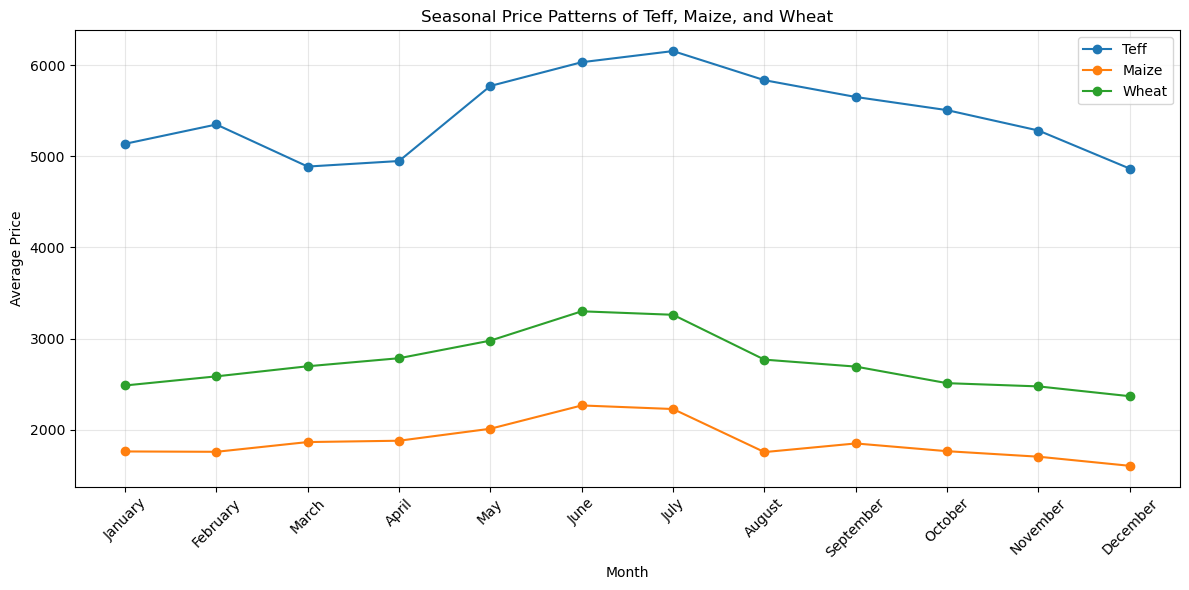

In [184]:
plt.figure(figsize=(12, 6))

for commodity in ["Teff", "Maize", "Wheat"]:
    data = seasonal_avg[
        seasonal_avg["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["month_name"],
        data["price"],
        marker="o",
        label=commodity
    )

plt.title("Seasonal Price Patterns of Teff, Maize, and Wheat")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/seasonal/Seasonal Price Patterns of T,M,W.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
# Highest and lowest seasonal months
seasonal_extremes = []

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = seasonal_avg[
        seasonal_avg["commodity_group"] == commodity
    ].copy()
    
    highest = data.loc[data["price"].idxmax()]
    lowest = data.loc[data["price"].idxmin()]
    
    seasonal_extremes.append({
        "Commodity": commodity,
        "Peak Month": highest["month_name"],
        "Peak Average Price": highest["price"],
        "Lowest Month": lowest["month_name"],
        "Lowest Average Price": lowest["price"]
    })

seasonal_extremes_df = pd.DataFrame(seasonal_extremes)

seasonal_extremes_df

,Commodity,Peak Month,Peak Average Price,Lowest Month,Lowest Average Price
0,Teff,July,6153.333096,December,4864.145479
1,Maize,June,2266.188780,December,1604.076404
2,Wheat,June,3298.882457,December,2367.697979


In [112]:
# Seasonal variation
seasonal_extremes_df["Seasonal Range"] = (
    seasonal_extremes_df["Peak Average Price"]
    - seasonal_extremes_df["Lowest Average Price"]
)

seasonal_extremes_df["Seasonal Variation (%)"] = (
    seasonal_extremes_df["Seasonal Range"]
    / seasonal_extremes_df["Lowest Average Price"]
    * 100
)

seasonal_extremes_df

,Commodity,Peak Month,Peak Average Price,Lowest Month,Lowest Average Price,Seasonal Range,Seasonal Variation (%)
0,Teff,July,6153.333096,December,4864.145479,1289.187617,26.503887
1,Maize,June,2266.188780,December,1604.076404,662.112376,41.276860
2,Wheat,June,3298.882457,December,2367.697979,931.184479,39.328685


Percentage Variation: Maize is the most seasonally volatile crop with a 41.28% price swing between its low and high months, closely followed by Wheat at 39.33%. Teff is much more stable in relative terms (26.50% variation), even though it experiences the largest absolute price swings (nearly 1,290 ETB)

In [113]:
# Seasonal index
seasonal_index = seasonal_avg.copy()

overall_avg = (
    seasonal_index
    .groupby("commodity_group")["price"]
    .transform("mean")
)

seasonal_index["seasonal_index"] = (
    seasonal_index["price"] / overall_avg
)

seasonal_index.head()

,month,month_name,commodity_group,price,seasonal_index
0,1,January,Maize,1761.611928,0.941867
3,2,February,Maize,1757.813373,0.939836
6,3,March,Maize,1864.680559,0.996973
9,4,April,Maize,1879.301573,1.004791
12,5,May,Maize,2010.733974,1.075063


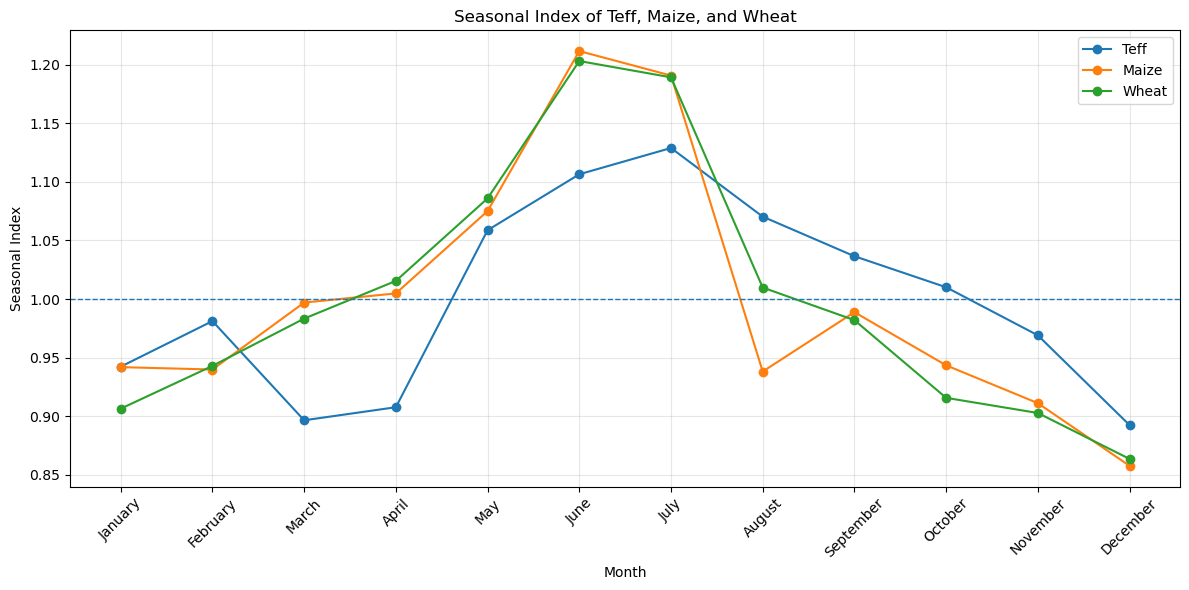

In [ ]:
plt.figure(figsize=(12, 6))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = seasonal_index[
        seasonal_index["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["month_name"],
        data["seasonal_index"],
        marker="o",
        label=commodity
    )

plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Seasonal Index of Teff, Maize, and Wheat")
plt.xlabel("Month")
plt.ylabel("Seasonal Index")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/seasonal/Seasonal Index of T,M,W.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Seasonal Index Trends: The index chart visually confirms this disparity, showing Maize and Wheat making extreme, synchronized swings from roughly 0.86 in December up to peaks above 1.20 in June. Teff's curve is noticeably flatter and less erratic, peaking lower around 1.13 and remaining much closer to the 1.00 annual baseline throughout the year.

### 2.5.3 Year-over-Year Patterns

In [115]:
# Annual average price
target_df["year"] = target_df["date"].dt.year

annual_avg = (
    target_df
    .groupby(["year", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

annual_avg.head()

,year,commodity_group,price
0,2000,Maize,127.741250
1,2000,Teff,241.187500
2,2000,Wheat,186.958333
3,2001,Maize,78.763958
4,2001,Teff,185.729167


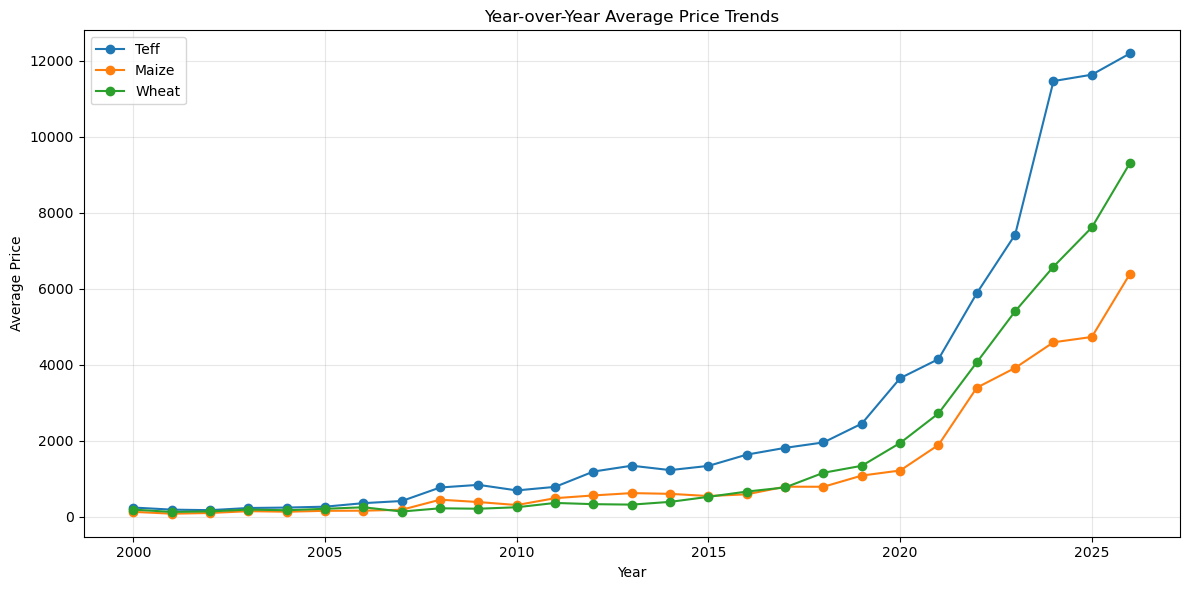

In [185]:
plt.figure(figsize=(12, 6))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = annual_avg[
        annual_avg["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["year"],
        data["price"],
        marker="o",
        label=commodity
    )

plt.title("Year-over-Year Average Price Trends")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/seasonal/y-o-y Average Price Trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
# Calculate Year-over-Year Percentage Change
annual_yoy = annual_avg.copy()

annual_yoy["YoY Change (%)"] = (
    annual_yoy
    .groupby("commodity_group")["price"]
    .pct_change()
    * 100
)

annual_yoy.head(10)

,year,commodity_group,price,YoY Change (%)
0,2000,Maize,127.741250,NaN
1,2000,Teff,241.187500,NaN
2,2000,Wheat,186.958333,NaN
3,2001,Maize,78.763958,-38.341015
4,2001,Teff,185.729167,-22.993867
5,2001,Wheat,125.162500,-33.053265
6,2002,Maize,97.587708,23.898939
7,2002,Teff,171.875000,-7.459338
8,2002,Wheat,139.600000,11.535004
9,2003,Maize,145.525833,49.123118


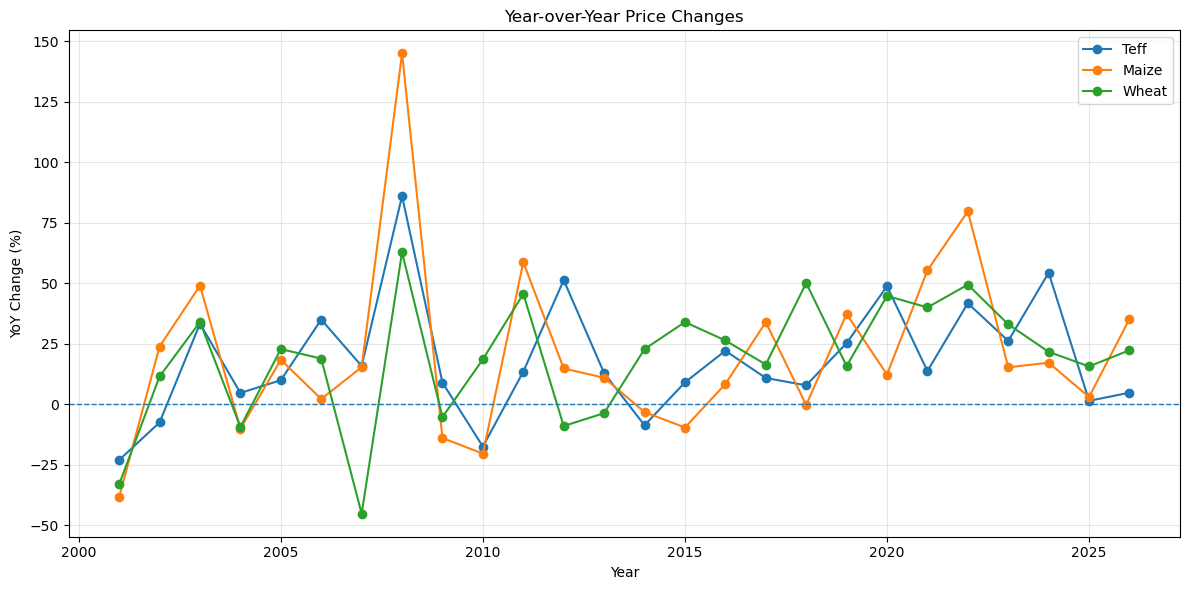

In [186]:
plt.figure(figsize=(12, 6))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = annual_yoy[
        annual_yoy["commodity_group"] == commodity
    ]
    
    plt.plot(
        data["year"],
        data["YoY Change (%)"],
        marker="o",
        label=commodity
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Year-over-Year Price Changes")
plt.xlabel("Year")
plt.ylabel("YoY Change (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/seasonal/y-o-y Price Changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [122]:
# Largest YoY Changesl
largest_yoy_changes = (
    annual_yoy
    .dropna(subset=["YoY Change (%)"])
    .sort_values("YoY Change (%)", ascending=False)
)

largest_yoy_changes.head(10)

,year,commodity_group,price,YoY Change (%)
24,2008,Maize,447.744386,145.093913
25,2008,Teff,769.020833,86.109711
66,2022,Maize,3397.101356,79.807654
26,2008,Wheat,221.259647,62.876873
33,2011,Maize,487.460912,58.777633
63,2021,Maize,1889.297413,55.380016
73,2024,Teff,11468.910314,54.422911
37,2012,Teff,1188.828000,51.358541
56,2018,Wheat,1156.979273,50.142770
68,2022,Wheat,4064.504670,49.479027


In [123]:
# monthly YoY changes
monthly_avg = (
    target_df
    .groupby(
        ["year", "month", "commodity_group"]
    )["price"]
    .mean()
    .reset_index()
)

monthly_avg = monthly_avg.sort_values(
    ["commodity_group", "month", "year"]
)

monthly_avg["YoY Change (%)"] = (
    monthly_avg
    .groupby(["commodity_group", "month"])["price"]
    .pct_change()
    * 100
)

monthly_avg.head(15)

,year,month,commodity_group,price,YoY Change (%)
0,2000,1,Maize,136.437500,NaN
36,2001,1,Maize,96.812500,-29.042602
72,2002,1,Maize,68.537500,-29.205939
108,2003,1,Maize,136.800000,99.598760
144,2004,1,Maize,105.950000,-22.551170
180,2005,1,Maize,129.145000,21.892402
216,2006,1,Maize,145.860833,12.943461
252,2007,1,Maize,150.665625,3.294093
288,2008,1,Maize,246.919355,63.885661
324,2009,1,Maize,394.303030,59.688993


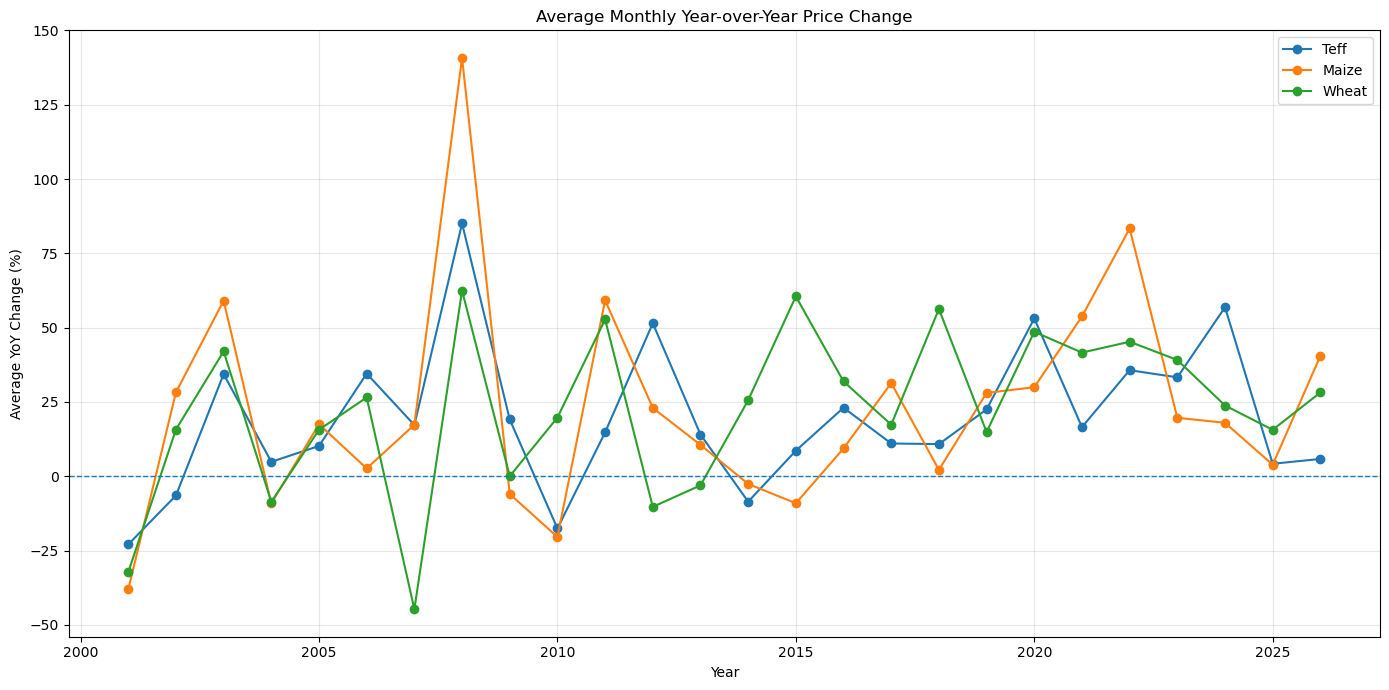

In [187]:
plt.figure(figsize=(14, 7))

for commodity in ["Teff", "Maize", "Wheat"]:
    
    data = monthly_avg[
        monthly_avg["commodity_group"] == commodity
    ]
    
    yearly_yoy = (
        data.groupby("year")["YoY Change (%)"]
        .mean()
        .reset_index()
    )
    
    plt.plot(
        yearly_yoy["year"],
        yearly_yoy["YoY Change (%)"],
        marker="o",
        label=commodity
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average Monthly Year-over-Year Price Change")
plt.xlabel("Year")
plt.ylabel("Average YoY Change (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/seasonal/Average Monthly y-o-y Price Change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.6 Relationships  
### 2.6.1 Correlation Analysis

In [125]:
# Create monthly period
target_df["year_month"] = target_df["date"].dt.to_period("M")

# Monthly average price for each commodity
monthly_commodity_prices = (
    target_df
    .groupby(["year_month", "commodity_group"])["price"]
    .mean()
    .reset_index()
)

monthly_commodity_prices.head()

,year_month,commodity_group,price
0,2000-01,Maize,136.4375
1,2000-01,Teff,222.0000
2,2000-01,Wheat,168.7500
3,2000-02,Maize,141.6250
4,2000-02,Teff,240.0000


In [126]:
# Convert Commodities Into Columns
commodity_panel = (
    monthly_commodity_prices
    .pivot(
        index="year_month",
        columns="commodity_group",
        values="price"
    )
    .reset_index()
)

commodity_panel.head()

commodity_group,year_month,Maize,Teff,Wheat
0,2000-01,136.4375,222.00,168.75
1,2000-02,141.6250,240.00,173.50
2,2000-03,140.8750,244.00,176.00
3,2000-04,143.1250,248.25,203.25
4,2000-05,135.1250,248.50,204.25


In [ ]:
# correlation_matrix
correlation_matrix = commodity_panel[
    ["Teff", "Maize", "Wheat"]
].corr()

correlation_matrix

commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.979367,0.986471
Maize,0.979367,1.000000,0.989446
Wheat,0.986471,0.989446,1.000000


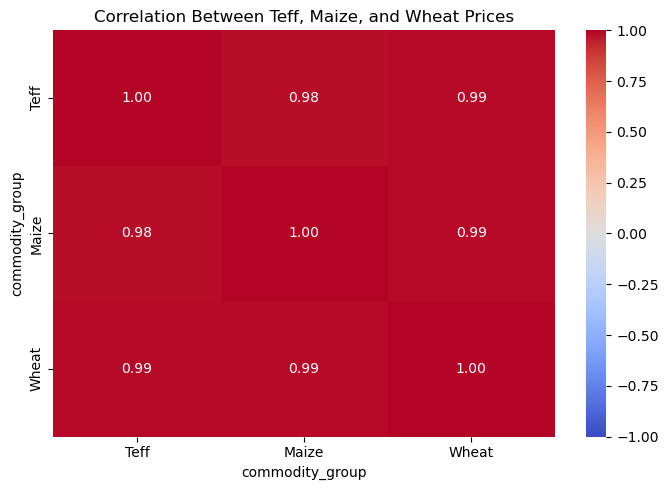

In [188]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Teff, Maize, and Wheat Prices")
plt.tight_layout()

plt.savefig(
    "../images/relationships/orrelation Between T,M,W.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [130]:
teff_maize_corr = correlation_matrix.loc["Teff", "Maize"]
teff_wheat_corr = correlation_matrix.loc["Teff", "Wheat"]
maize_wheat_corr = correlation_matrix.loc["Maize", "Wheat"]

print(f"Teff–Maize correlation: {teff_maize_corr:.3f}")
print(f"Teff–Wheat correlation: {teff_wheat_corr:.3f}")
print(f"Maize–Wheat correlation: {maize_wheat_corr:.3f}")

Teff–Maize correlation: 0.979
Teff–Wheat correlation: 0.986
Maize–Wheat correlation: 0.989


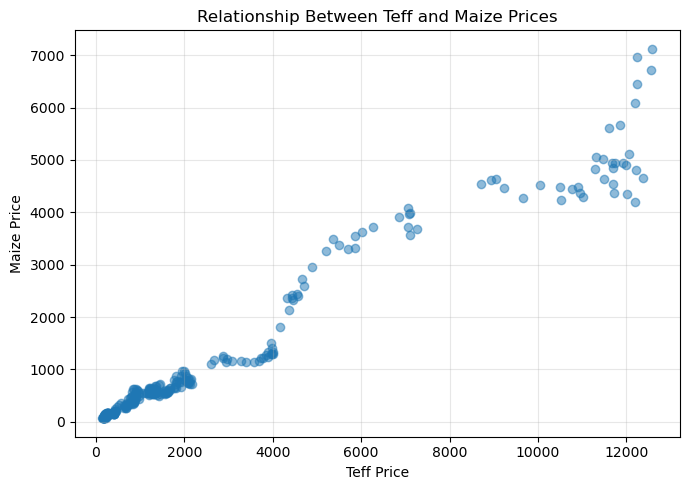

In [189]:
## Teff vs Maize
plt.figure(figsize=(7, 5))

plt.scatter(
    commodity_panel["Teff"],
    commodity_panel["Maize"],
    alpha=0.5
)

plt.xlabel("Teff Price")
plt.ylabel("Maize Price")
plt.title("Relationship Between Teff and Maize Prices")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/relationships/Relationship Between Teff and Maize Prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

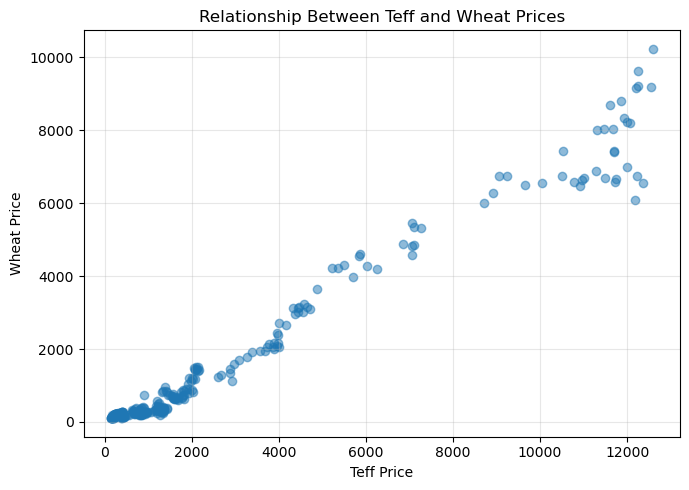

In [190]:
## Teff vs Wheat
plt.figure(figsize=(7, 5))

plt.scatter(
    commodity_panel["Teff"],
    commodity_panel["Wheat"],
    alpha=0.5
)

plt.xlabel("Teff Price")
plt.ylabel("Wheat Price")
plt.title("Relationship Between Teff and Wheat Prices")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/relationships/Relationship Between Teff and Wheat Prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

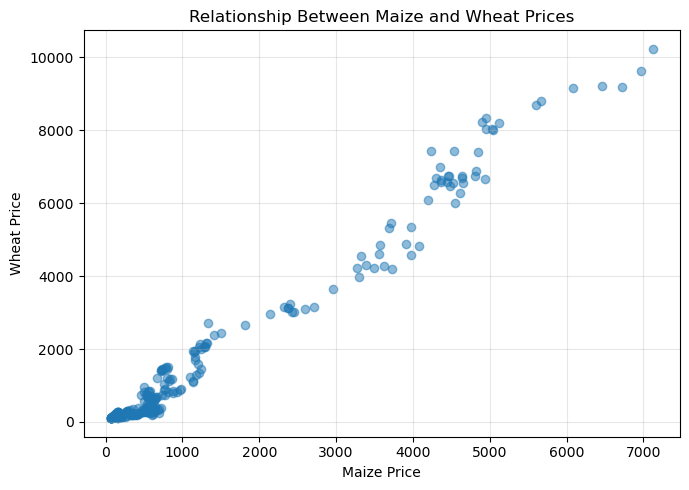

In [191]:
## Maize vs Wheat
plt.figure(figsize=(7, 5))

plt.scatter(
    commodity_panel["Maize"],
    commodity_panel["Wheat"],
    alpha=0.5
)

plt.xlabel("Maize Price")
plt.ylabel("Wheat Price")
plt.title("Relationship Between Maize and Wheat Prices")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/relationships/Relationship Between Maize and Wheat Prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
monthly_returns = commodity_panel.copy()

for commodity in ["Teff", "Maize", "Wheat"]:
    monthly_returns[commodity] = (
        monthly_returns[commodity]
        .pct_change(fill_method=None) * 100
    )

monthly_returns.head()

commodity_group,year_month,Maize,Teff,Wheat
0,2000-01,NaN,NaN,NaN
1,2000-02,3.802107,8.108108,2.814815
2,2000-03,-0.529568,1.666667,1.440922
3,2000-04,1.597161,1.741803,15.482955
4,2000-05,-5.589520,0.100705,0.492005


In [135]:
return_correlation = monthly_returns[
    ["Teff", "Maize", "Wheat"]
].corr()

return_correlation

commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.460591,0.146488
Maize,0.460591,1.000000,0.032976
Wheat,0.146488,0.032976,1.000000


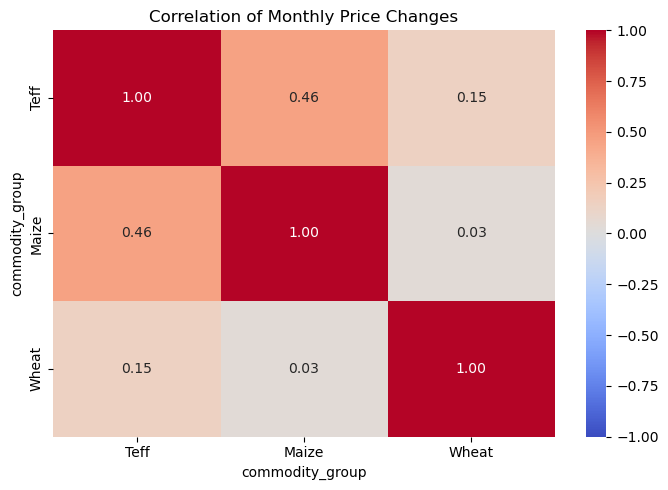

In [192]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    return_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation of Monthly Price Changes")
plt.tight_layout()

plt.savefig(
    "../images/relationships/Correlation of Monthly Price Changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Commodity relationships:*** Teff, Maize, and Wheat exhibit extremely strong positive correlations in their price levels, with coefficients between 0.979 and 0.989. This indicates highly synchronized long-term price trends. However, correlations between monthly percentage changes are substantially weaker: 0.461 for Teff–Maize, 0.146 for Teff–Wheat, and 0.033 for Maize–Wheat. This difference indicates that the strong relationship between commodity price levels is largely associated with their common long-term trends, while short-term price movements are considerably less synchronized.

In [139]:
commodity_panel[["Teff", "Maize", "Wheat"]].corr()

commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.979367,0.986471
Maize,0.979367,1.000000,0.989446
Wheat,0.986471,0.989446,1.000000


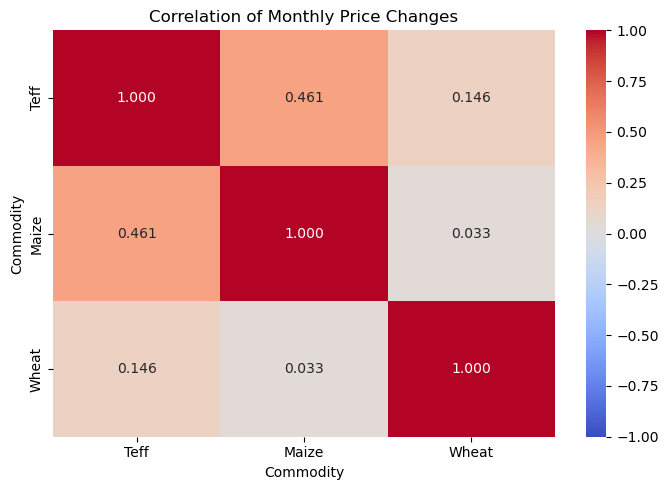

In [193]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    return_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation of Monthly Price Changes")
plt.xlabel("Commodity")
plt.ylabel("Commodity")
plt.tight_layout()

plt.savefig(
    "../images/relationships/Correlation of Monthly Price Changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Correlation by Period

In [142]:
pre_2020 = commodity_panel[
    commodity_panel["year_month"] < "2020-01"
].copy()

pre_2020[["Teff", "Maize", "Wheat"]].corr()

commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.966088,0.875270
Maize,0.966088,1.000000,0.797432
Wheat,0.875270,0.797432,1.000000


In [144]:
post_2020 = commodity_panel[
    commodity_panel["year_month"] >= "2020-01"
].copy()

post_2020[["Teff", "Maize", "Wheat"]].corr()

commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.920266,0.959297
Maize,0.920266,1.000000,0.973883
Wheat,0.959297,0.973883,1.000000


In [145]:
pre_2020_returns = monthly_returns[
    monthly_returns["year_month"] < "2020-01"
]

post_2020_returns = monthly_returns[
    monthly_returns["year_month"] >= "2020-01"
]

print("Pre-2020 monthly-change correlation:")
display(
    pre_2020_returns[["Teff", "Maize", "Wheat"]].corr()
)

print("2020 onward monthly-change correlation:")
display(
    post_2020_returns[["Teff", "Maize", "Wheat"]].corr()
)

Pre-2020 monthly-change correlation:


commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.448305,0.133973
Maize,0.448305,1.000000,-0.008504
Wheat,0.133973,-0.008504,1.000000


2020 onward monthly-change correlation:


commodity_group,Teff,Maize,Wheat
commodity_group,,,
Teff,1.000000,0.499029,0.396823
Maize,0.499029,1.000000,0.326256
Wheat,0.396823,0.326256,1.000000


Before 2020, short-term price changes were only moderately synchronized between Teff and Maize and showed little relationship between Wheat and the other commodities. From 2020 onward, all three commodities exhibited positive monthly price-change correlations, suggesting greater synchronization in short-term price movements during the recent period.

In [146]:
comparison_df = pd.DataFrame({
    "Commodity Pair": [
        "Teff–Maize",
        "Teff–Wheat",
        "Maize–Wheat"
    ],
    "Pre-2020": [
        0.448305,
        0.133973,
        -0.008504
    ],
    "2020 onward": [
        0.499029,
        0.396823,
        0.326256
    ]
})

comparison_df

,Commodity Pair,Pre-2020,2020 onward
0,Teff–Maize,0.448305,0.499029
1,Teff–Wheat,0.133973,0.396823
2,Maize–Wheat,-0.008504,0.326256


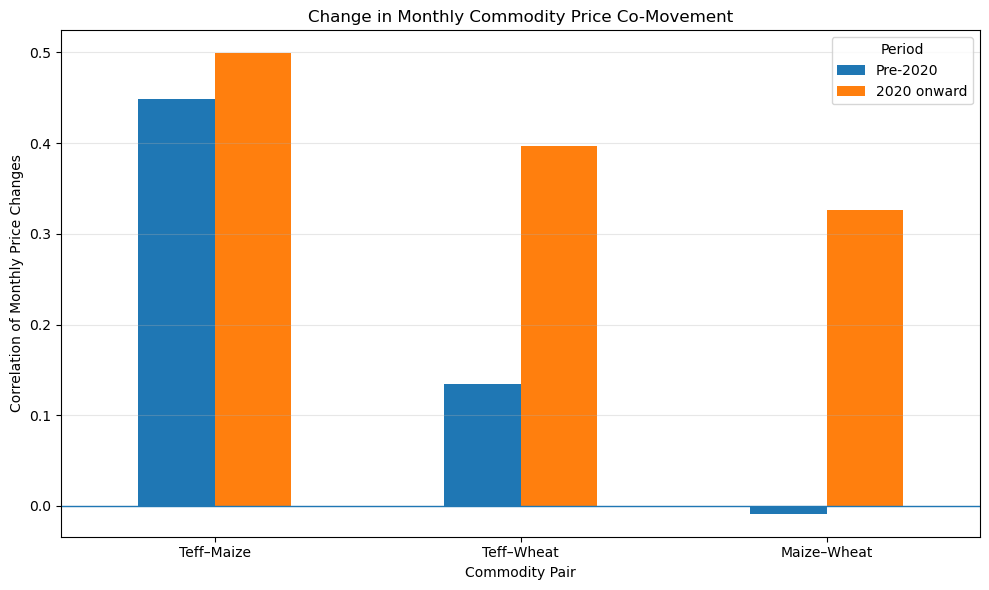

In [194]:
comparison_plot = comparison_df.set_index("Commodity Pair")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(0, linewidth=1)
plt.title("Change in Monthly Commodity Price Co-Movement")
plt.xlabel("Commodity Pair")
plt.ylabel("Correlation of Monthly Price Changes")
plt.xticks(rotation=0)
plt.legend(title="Period")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../images/relationships/Change in Monthly Commodity Price Co-Movement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Strong long-term relationships:*** Teff, Maize, and Wheat prices exhibit strong positive correlations throughout the study period. However, the strength of these relationships differs across periods. Before 2020, Teff–Maize showed a correlation of 0.966, while Teff–Wheat and Maize–Wheat were 0.875 and 0.797, respectively. From 2020 onward, the correlations increased for the Wheat relationships to 0.959 with Teff and 0.974 with Maize, while Teff–Maize remained strongly correlated at 0.920.

***Short-term co-movement:*** Monthly percentage changes show substantially weaker relationships than price levels. Before 2020, Teff–Maize had moderate co-movement (0.448), while Teff–Wheat (0.134) and Maize–Wheat (-0.009) showed weak or negligible relationships. From 2020 onward, all three pairwise correlations became positive: Teff–Maize (0.499), Teff–Wheat (0.397), and Maize–Wheat (0.326). This indicates increased synchronization in short-term commodity-price movements during the post-2020 period.